<h1>Задание</h1>

Выбрать модель (или несколько моделей) для обучения. Можно брать предобученные на ImageNet, но нельзя использовать модели, предобученные на задачу распознавания лиц.
Обучить эту модель (модели) на CE loss. Добиться accuracy > 0.7.
Реализовать ArcFace loss.
Обучить модель (модели) на ArcFace loss. Добиться accuracy > 0.7.
Написать небольшой отчет по обучению, сравнить CE loss и ArcFace loss.

<h1>Импорт библиотек</h1>

In [1]:
import pandas as pd
from collections import defaultdict
from tqdm.notebook import tqdm
import random
import cv2
import sys
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from torchvision import datasets
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image


os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from utils import align_face

<h1>Подготовка данных</h1>

Для начала сделаем словарик вида identity: image_filenames, при этом чтобы у каждого человека было 10+ фоток

In [2]:
identities_dict =  defaultdict(list)

with open('../data/celeba/Anno/identity_CelebA.txt', 'r') as file:
    for line in file:
        image_name, id = line.strip().split()
        identities_dict[int(id)].append(image_name)

identities_dict = {id: images for id, images in identities_dict.items() if len(images) >= 10}

In [3]:
len(identities_dict)

8369

Теперь разобъем на train/val и на query/distractors

In [4]:
random.seed(42)
all_identities = list(identities_dict.keys())
random.shuffle(all_identities)

train_val_id = all_identities[:2000]
query_id = all_identities[2000:2100]
distractor_id = all_identities[2100:2600]

Нужно пройтись по датасету, выровнять фото и сохранить их по папкам

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


Загружаем модель для выравнивания и bbox'ы

In [6]:
os.makedirs('../data/celeba/alligned_img/', exist_ok=True)
shg_model = torch.jit.load("../notebooks/models/shg/shg_final.pt").to(device)
bboxes = pd.read_csv('../data/celeba/Anno/list_bbox_celeba.txt', sep=r'\s+', index_col=0)

In [ ]:
def prepare_and_save(image_name, bboxes, model, save_path):
    """Обрезает и выравнивает лицо на изображении, затем сохраняет результат."""
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
    image = Image.open(f'../data/celeba/img_celeba/{image_name}').convert('RGB')
    bbox = bboxes.loc[image_name]
    x1, y1, w, h = bbox['x_1'], bbox['y_1'], bbox['width'], bbox['height']
    x2, y2 = x1 + w, y1 + h
    image = image.crop((x1 - 0.2 * w, y1 - 0.2 * h, x2 + 0.2 * w, y2 + 0.2 * h))
    image = transform(image)
    image = align_face(image, model)
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    cv2.imwrite(save_path, image)

In [ ]:
def save_class(image_list, path):
    """Обрабатывает и сохраняет изображения из списка в указанную папку."""
    for image_name in image_list:
        save_path = os.path.join(path, image_name)
        prepare_and_save(image_name, bboxes, shg_model, save_path)

Тут мы проходимся по всем людям из train/val части, делим список картинок каждого человека на train и val, и сохраняем их по папкам

In [9]:
# for id in train_val_id:
#     images = identities_dict[id]
#     train_img, val_img = train_test_split(images, test_size=0.2, random_state=42)
#     train_path = f'../data/celeba/alligned_img/train/{id}'
#     val_path =f'../data/celeba/alligned_img/val/{id}'
#     os.makedirs(train_path, exist_ok=True)
#     os.makedirs(val_path, exist_ok=True)

#     save_class(train_img, train_path)
#     save_class(val_img, val_path)
        

Аналогично для query и distractor

In [10]:
# for id in query_id:
#     images = identities_dict[id]
#     query_path = f'../data/celeba/alligned_img/query/{id}'
#     os.makedirs(query_path, exist_ok=True)
#     save_class(images, query_path)

# for id in distractor_id:
#     images = identities_dict[id]
#     distractor_path = f'../data/celeba/alligned_img/distractor/{id}'
#     os.makedirs(distractor_path, exist_ok=True)
#     save_class(images, distractor_path)

<h1>Dataloader</h1>

Создадим даталоадер для train, val

In [11]:
transform=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

train_data = datasets.ImageFolder('../data/celeba/alligned_img/train', transform)
val_data = datasets.ImageFolder('../data/celeba/alligned_img/val', transform)

train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
val_loader = DataLoader(val_data, batch_size=256, shuffle=False)

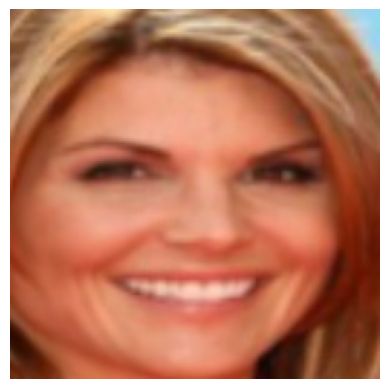

In [12]:
x, y = next(iter(train_loader))
x[0] = x[0]*0.5+0.5
plt.imshow(x[0].permute(1,2,0))
plt.axis('off')
plt.show()

<h1>Подготовка моделей</h1>

<h2>ResNet18</h2>

In [13]:
resnet_18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

In [14]:
resnet_18

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Надо заменить в последнем слое out features на количество людей в датасете(2000), и также разморозить предпоследний слой layer4

In [15]:
resnet_18.fc = nn.Linear(resnet_18.fc.in_features, 2000)

for param in resnet_18.parameters():
    param.requires_grad = False

for param in resnet_18.layer4.parameters():
    param.requires_grad = True

for param in resnet_18.fc.parameters():
    param.requires_grad = True

resnet_18 = resnet_18.to(device)

<h2>ResNet50</h2>

Сделаем resnet50 аналогично

In [16]:
resnet_50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1).to(device)

In [17]:
resnet_50

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [18]:
resnet_50.fc = nn.Linear(resnet_50.fc.in_features, 2000)

for param in resnet_50.parameters():
    param.requires_grad = False

for param in resnet_50.layer4.parameters():
    param.requires_grad = True

for param in resnet_50.fc.parameters():
    param.requires_grad = True

resnet_50 = resnet_50.to(device)

<h1>Обучение</h1>

In [19]:
def train_single_epoch(model, dataloader, optimizer, criterion, metric):
    model.train()
    avg_loss = 0
    avg_score = 0

    for x_batch, y_batch in tqdm(dataloader):
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        metric_score = metric(y_pred, y_batch)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        avg_loss += loss.item()
        avg_score += metric_score
    
    avg_loss /= len(dataloader)
    avg_score /= len(dataloader)

    return avg_loss, avg_score

In [20]:
def val_single_epoch(model, dataloader, criterion, metric):
    model.eval()
    avg_loss = 0
    avg_score = 0

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            metric_score = metric(y_pred, y_batch)

            avg_loss += loss.item()
            avg_score += metric_score

    avg_loss /= len(dataloader)
    avg_score /= len(dataloader)

    return avg_loss, avg_score

In [21]:
def train(model, epochs, train_dataloader, val_dataloader, optimizer, criterion, metric, save_path, scheduler=None, name_postfix=""):
    total_train_loss = []
    total_train_score = []
    total_val_loss = []
    total_val_score = []

    best_score = float('-inf')
    best_epoch = -1
    best_model_state = None
    
    for epoch in tqdm(range(epochs)):
        train_loss, train_score = train_single_epoch(model, train_dataloader, optimizer, criterion, metric)
        val_loss, val_score = val_single_epoch(model, val_dataloader, criterion, metric)
        print(f'Epoch #{epoch}')
        print(f'Train: loss = {train_loss}, {metric.__name__} = {train_score}')
        print(f'Val: loss = {val_loss}, {metric.__name__} = {val_score}')
        if scheduler:
            scheduler.step(val_score)
        if val_score > best_score:
            best_score = val_score
            best_epoch = epoch
            best_model_state = model.state_dict()

        total_train_loss.append(train_loss)
        total_train_score.append(train_score)
        total_val_loss.append(val_loss)
        total_val_score.append(val_score)

        if epoch > 0:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            axes[0].plot(total_train_loss, label='Train')
            axes[0].plot(total_val_loss, label='Val')
            axes[0].set(xlabel='Epoch', ylabel='Loss')
            axes[1].plot(total_train_score, label='Train')
            axes[1].plot(total_val_score, label='Val')
            axes[1].set(xlabel='Epoch', ylabel=metric.__name__)
            plt.show()

    statistics = {'train loss': total_train_loss,
                  'train_score': total_train_score,
                  'val_loss': total_val_loss,
                  'val_score': total_val_score}
    
    os.makedirs(save_path, exist_ok=True)
    filename = f"weights_{best_score:.2f}".replace(".", "_") + name_postfix + ".pt"
    full_path = os.path.join(save_path, filename)
    torch.save(best_model_state, full_path)

    print(f'Best epoch = {best_epoch}, {metric} = {best_score}')
    
    return model, statistics
         

<h2>ResNet18 CE loss</h2>

<h3>Попытка 1</h3>

In [59]:
def accuracy(outputs, labels):
    """Считает метрику accuracy"""
    _, preds = torch.max(outputs, dim=1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct / total

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([p for p in resnet_18.parameters() if p.requires_grad])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #0
Train: loss = 6.575543957696834, accuracy = 0.042574551691592855
Val: loss = 5.064539495267366, accuracy = 0.11895391380236305


  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #1
Train: loss = 3.7721997852056797, accuracy = 0.2947834801981995
Val: loss = 3.594831999979521, accuracy = 0.30417981337271754


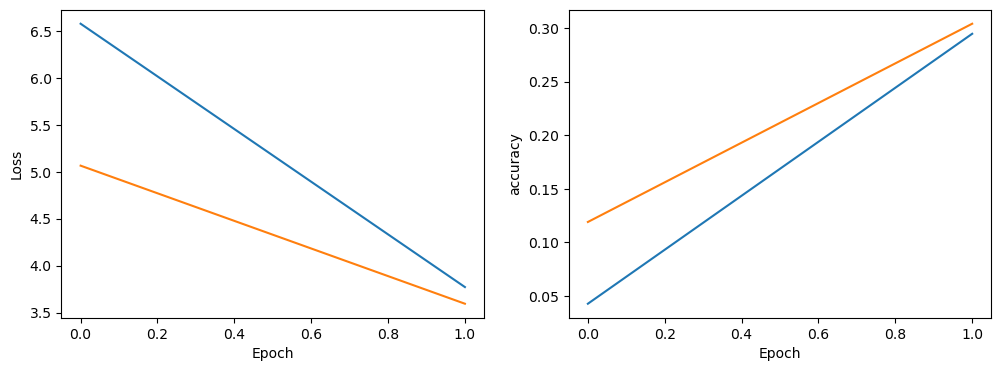

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #2
Train: loss = 1.9933594901796798, accuracy = 0.6134448848373748
Val: loss = 2.8269574516697933, accuracy = 0.4284644367615467


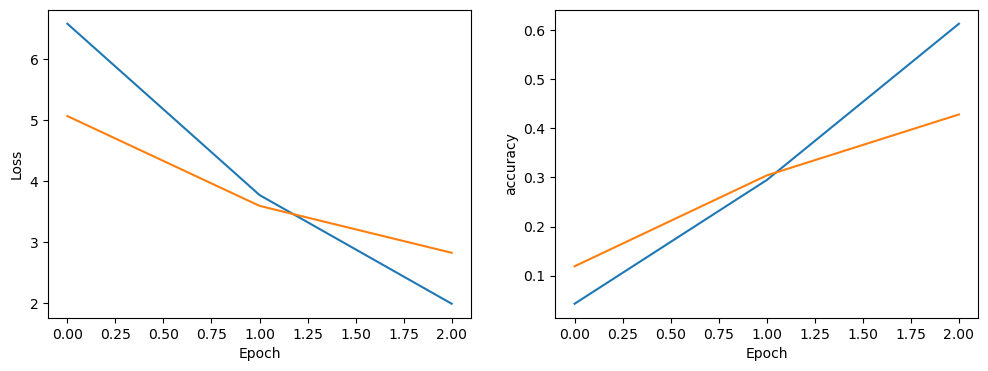

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #3
Train: loss = 0.848159886581797, accuracy = 0.8537646222048787
Val: loss = 2.5221780162108574, accuracy = 0.4933014735499463


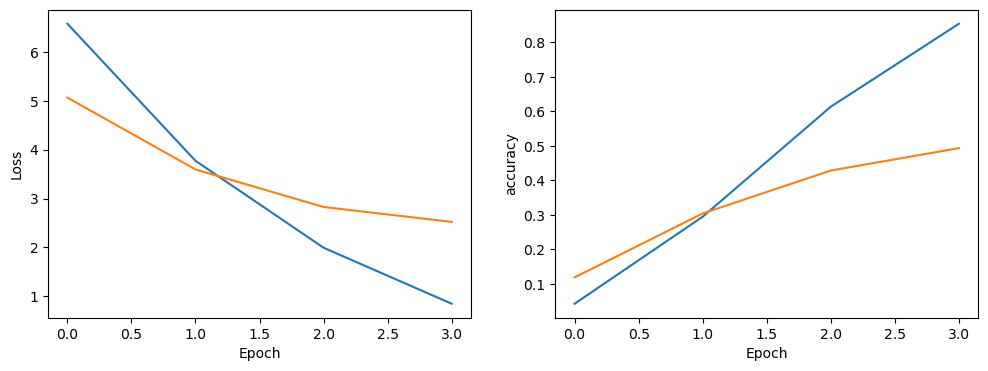

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #4
Train: loss = 0.24450811628304736, accuracy = 0.9765361255808044
Val: loss = 2.328106585301851, accuracy = 0.5401617883995704


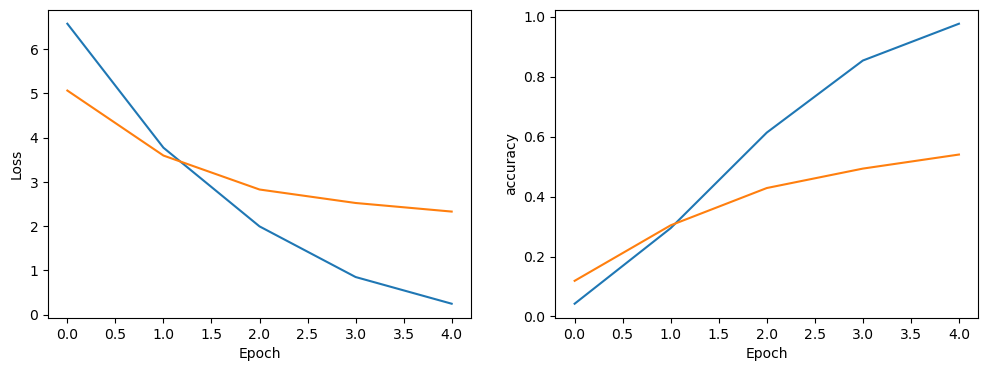

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #5
Train: loss = 0.06767853289108042, accuracy = 0.9944630735443589
Val: loss = 2.146506190299988, accuracy = 0.5796019065520945


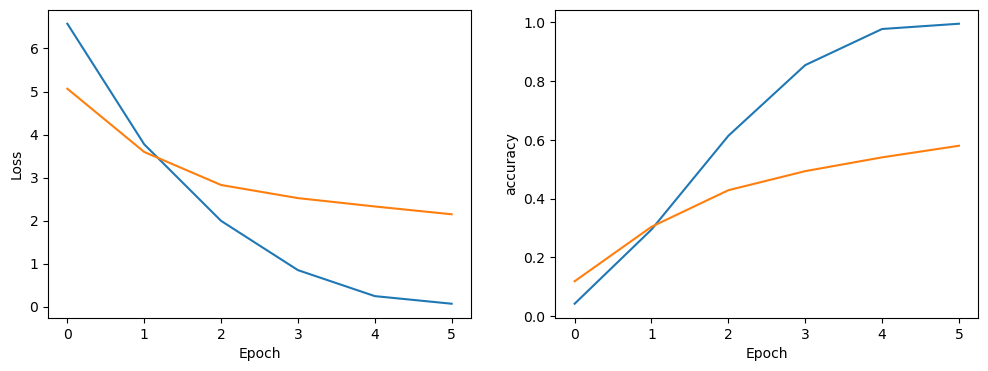

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #6
Train: loss = 0.033317299238340536, accuracy = 0.9962863116197183
Val: loss = 2.0872922853419653, accuracy = 0.5935423100161117


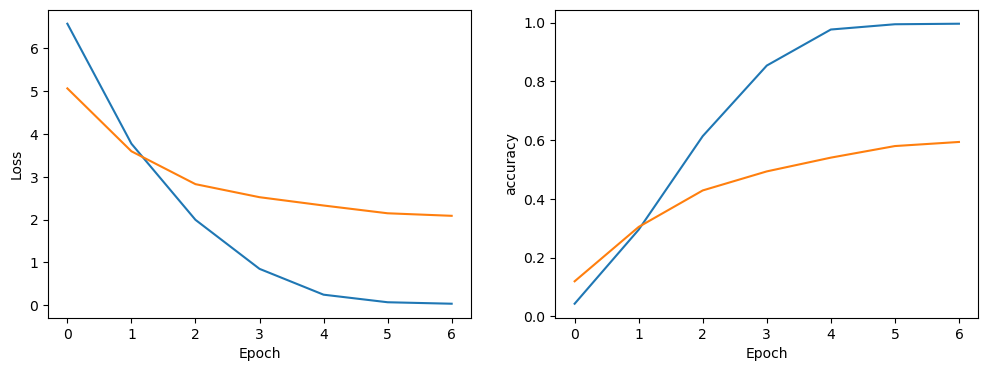

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #7
Train: loss = 0.02159552250555913, accuracy = 0.9974603986677799
Val: loss = 2.253003245905826, accuracy = 0.5654643024973147


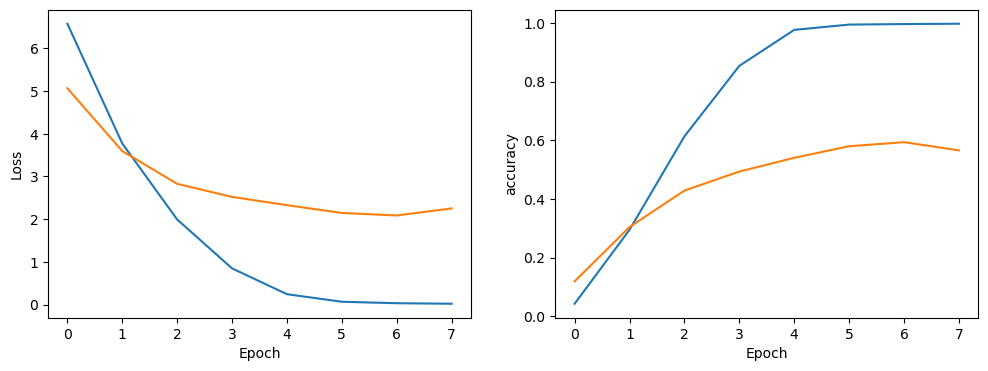

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #8
Train: loss = 0.0203163784758096, accuracy = 0.9976617517605634
Val: loss = 2.2255692168285974, accuracy = 0.5741474221267454


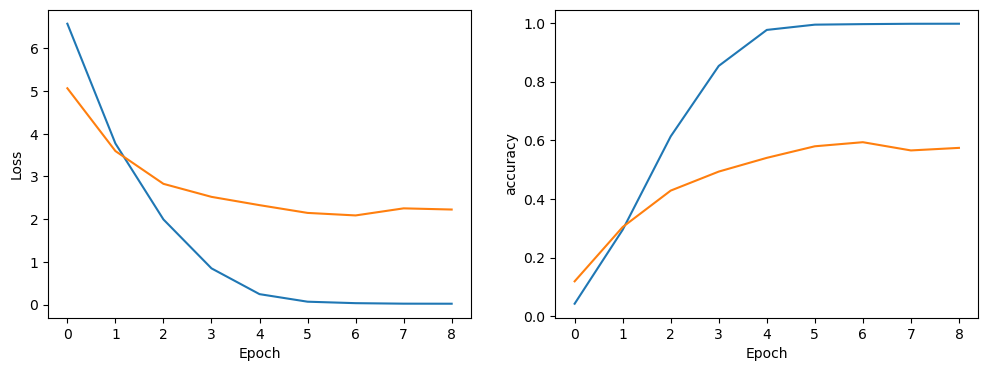

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #9
Train: loss = 0.017588185205478484, accuracy = 0.9981481187382024
Val: loss = 2.224473686594712, accuracy = 0.5776173133727175


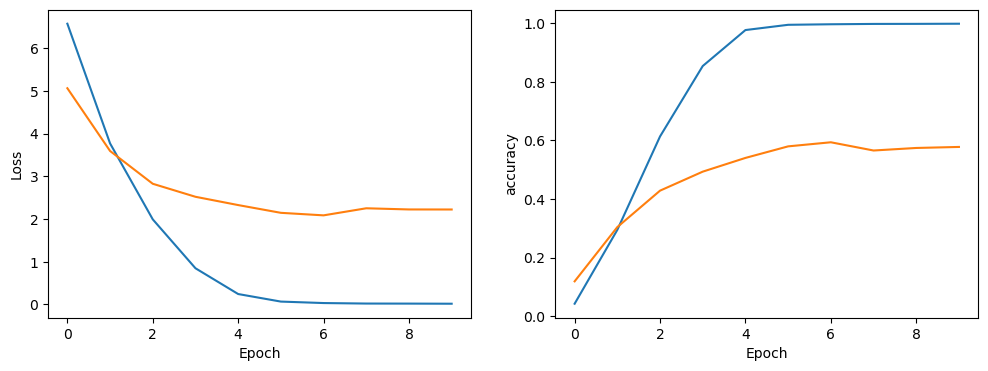

Best epoch = 6, <function accuracy at 0x000002065344B6A0> = 0.5935423100161117


In [24]:
resnet_18, resnet18_stats = train(resnet_18, 10, train_loader, val_loader, optimizer, criterion, accuracy, './models/resnet18_CE', scheduler, '_atempt_1')

<h3>Попытка 2</h3>

Прекрасно видно, что модель переобучилась. Хочу оценить как там вообще resnet предобучен, заморозим всё, оставим только последний слой

In [25]:
resnet_18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

resnet_18.fc = nn.Linear(resnet_18.fc.in_features, 2000)

for param in resnet_18.parameters():
    param.requires_grad = False

for param in resnet_18.fc.parameters():
    param.requires_grad = True

resnet_18 = resnet_18.to(device)

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([p for p in resnet_18.parameters() if p.requires_grad])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #0
Train: loss = 7.517735608866517, accuracy = 0.007893892024829388
Val: loss = 6.846123770663612, accuracy = 0.033628994360902255


  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #1
Train: loss = 6.092636239360756, accuracy = 0.10084585314723392
Val: loss = 6.214173065988641, accuracy = 0.08031308740601505


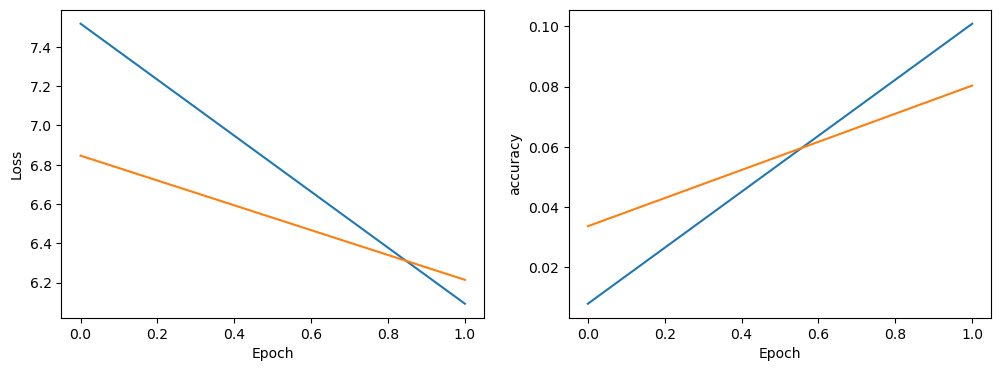

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #2
Train: loss = 5.150386215935291, accuracy = 0.22146089325903878
Val: loss = 5.761460856387489, accuracy = 0.12357344253490869


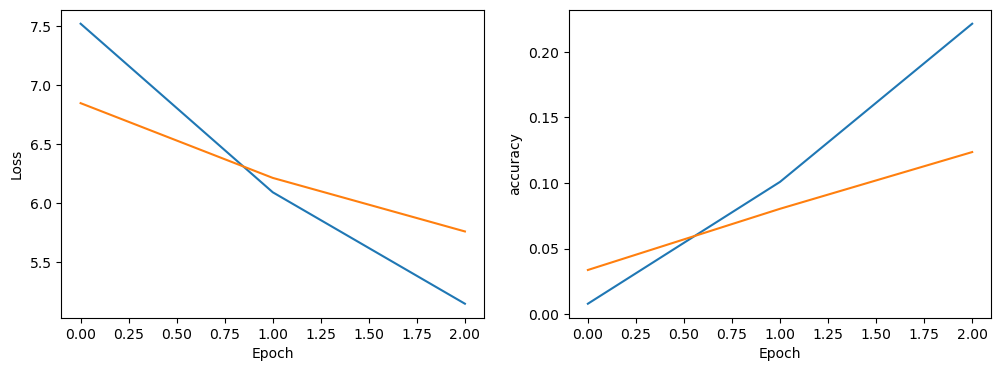

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #3
Train: loss = 4.415762857652046, accuracy = 0.332245081312618
Val: loss = 5.439531188262136, accuracy = 0.15769124261546724


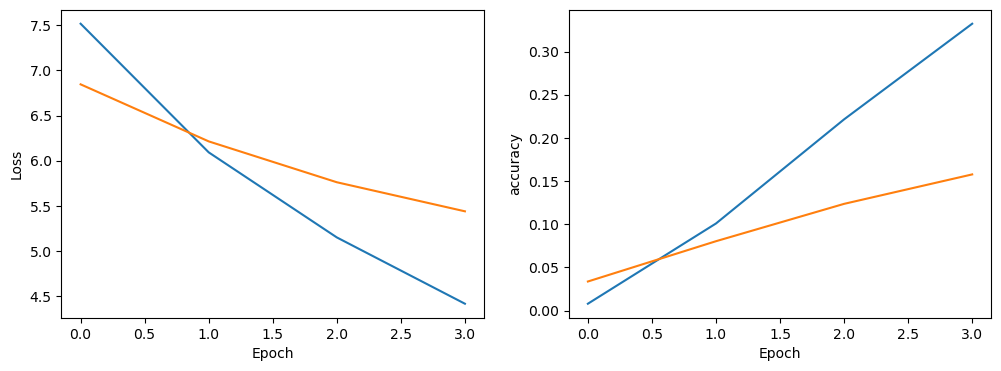

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #4
Train: loss = 3.8301676041643384, accuracy = 0.42679368738202406
Val: loss = 5.203179083372417, accuracy = 0.18333361305048335


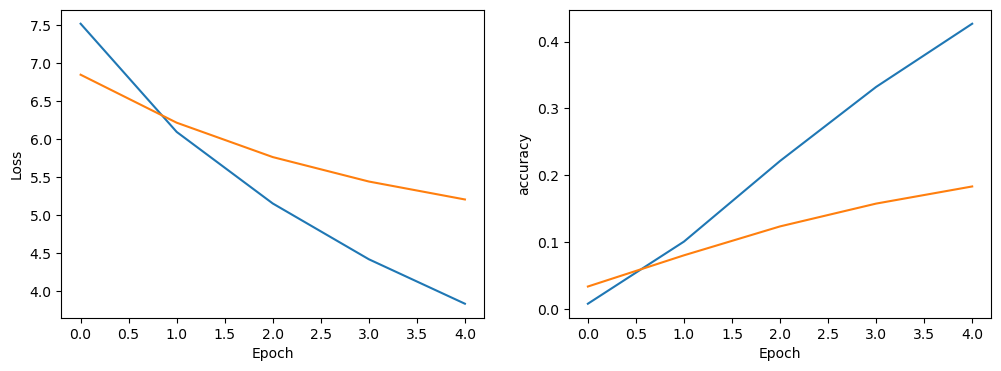

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #5
Train: loss = 3.3667844248489596, accuracy = 0.49616521616814285
Val: loss = 5.046002149581909, accuracy = 0.19364468649301828


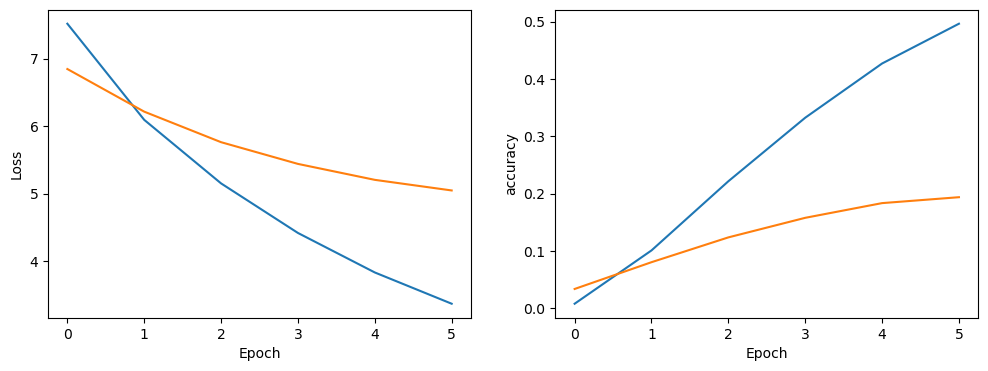

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #6
Train: loss = 2.980873259020523, accuracy = 0.5577134683098591
Val: loss = 4.907253240284167, accuracy = 0.21200532022019336


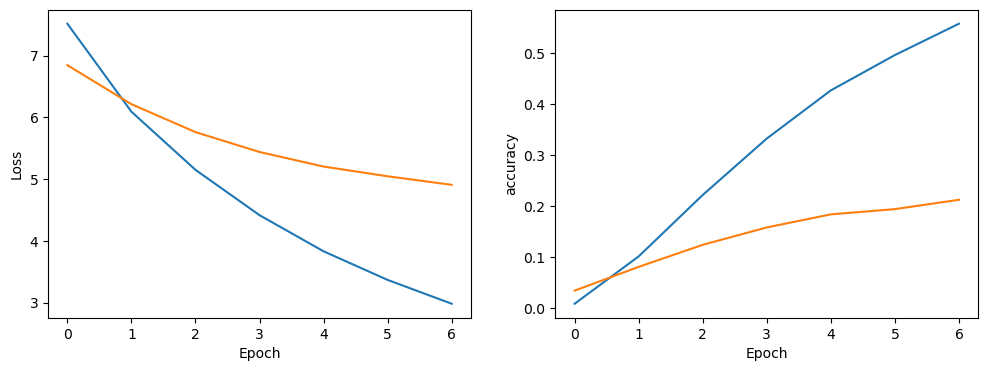

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #7
Train: loss = 2.6585145416394087, accuracy = 0.6062211299368375
Val: loss = 4.81254065664191, accuracy = 0.22372407022019336


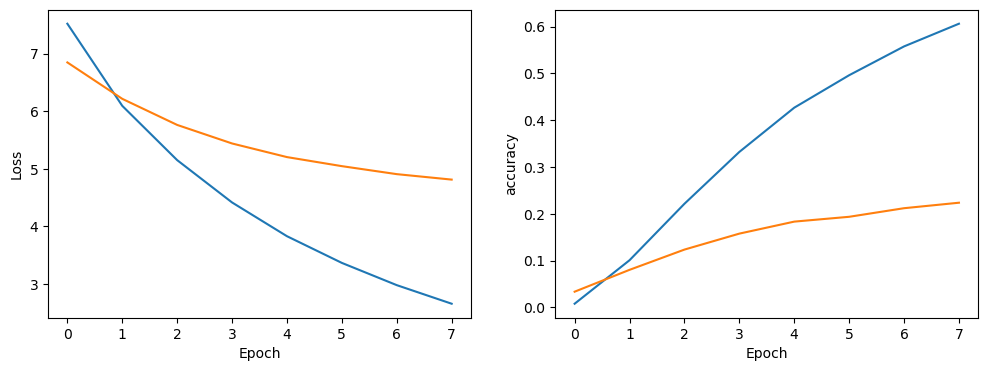

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #8
Train: loss = 2.38941018010529, accuracy = 0.6466315612748657
Val: loss = 4.745519612964831, accuracy = 0.22601705155746507


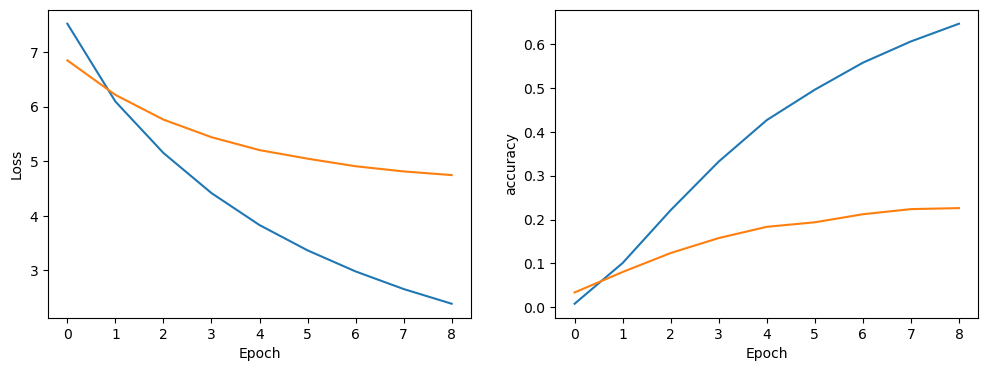

  0%|          | 0/142 [00:00<?, ?it/s]

Epoch #9
Train: loss = 2.1543136835098267, accuracy = 0.6836825155183679
Val: loss = 4.704867049267418, accuracy = 0.22994637822234157


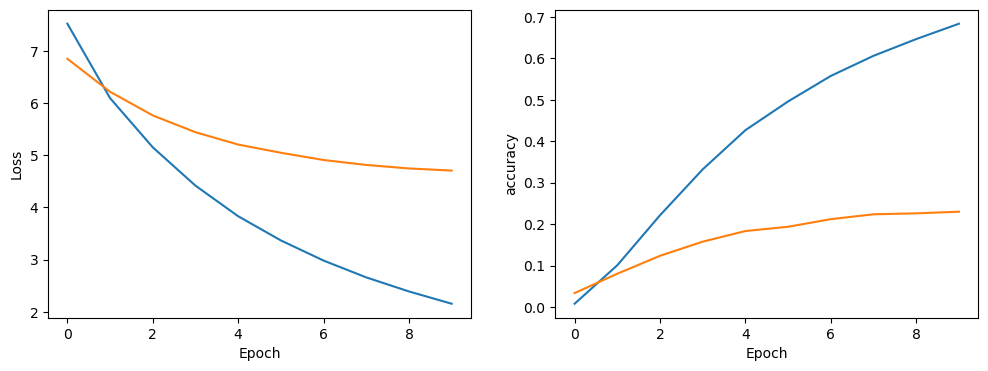

Best epoch = 9, <function accuracy at 0x000002065344B6A0> = 0.22994637822234157


In [27]:
resnet_18, resnet18_stats = train(resnet_18, 10, train_loader, val_loader, optimizer, criterion, accuracy, './models/resnet18_CE', scheduler, '_atempt_2')

Очевидный результат, модель обученная на ImageNet не умеет классифицировать лица

<h3>Попытка 3</h3>

Для уменьшения переобучения пробуем взять людей, у которых 25+ фото а не 10+, как в прошлых попытках

In [28]:
identities_dict =  defaultdict(list)

with open('../data/celeba/Anno/identity_CelebA.txt', 'r') as file:
    for line in file:
        image_name, id = line.strip().split()
        identities_dict[int(id)].append(image_name)

identities_dict = {id: images for id, images in identities_dict.items() if len(images) >= 25}

len(identities_dict)

3661

In [29]:
random.seed(42)
all_identities = list(identities_dict.keys())
random.shuffle(all_identities)

train_val_id = all_identities[:2000]
query_id = all_identities[2000:2100]
distractor_id = all_identities[2100:2600]

In [30]:
# os.makedirs('../data/celeba/alligned_img25/', exist_ok=True)

# for id in train_val_id:
#     images = identities_dict[id]
#     train_img, val_img = train_test_split(images, test_size=0.2, random_state=42)
#     train_path = f'../data/celeba/alligned_img25/train/{id}'
#     val_path =f'../data/celeba/alligned_img25/val/{id}'
#     os.makedirs(train_path, exist_ok=True)
#     os.makedirs(val_path, exist_ok=True)

#     save_class(train_img, train_path)
#     save_class(val_img, val_path)
        

In [31]:
transform=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

train_data = datasets.ImageFolder('../data/celeba/alligned_img25/train', transform)
val_data = datasets.ImageFolder('../data/celeba/alligned_img25/val', transform)

train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
val_loader = DataLoader(val_data, batch_size=256, shuffle=False)

In [32]:
resnet_18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

resnet_18.fc = nn.Linear(resnet_18.fc.in_features, 2000)

for param in resnet_18.parameters():
    param.requires_grad = False

for param in resnet_18.layer4.parameters():
    param.requires_grad = True

for param in resnet_18.fc.parameters():
    param.requires_grad = True

resnet_18 = resnet_18.to(device)

In [33]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([p for p in resnet_18.parameters() if p.requires_grad])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #0
Train: loss = 6.39108718956373, accuracy = 0.051303411425131035
Val: loss = 4.739254363039707, accuracy = 0.14941821808510639


  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #1
Train: loss = 3.4984221142299927, accuracy = 0.3348495714690466
Val: loss = 3.3954568416514297, accuracy = 0.3378656914893617


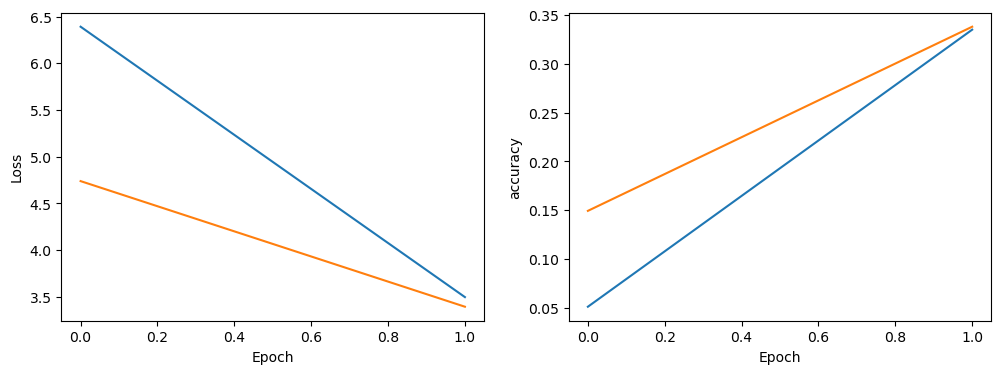

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #2
Train: loss = 1.831983817216441, accuracy = 0.6333420766043348
Val: loss = 2.7210932386682387, accuracy = 0.45530252659574466


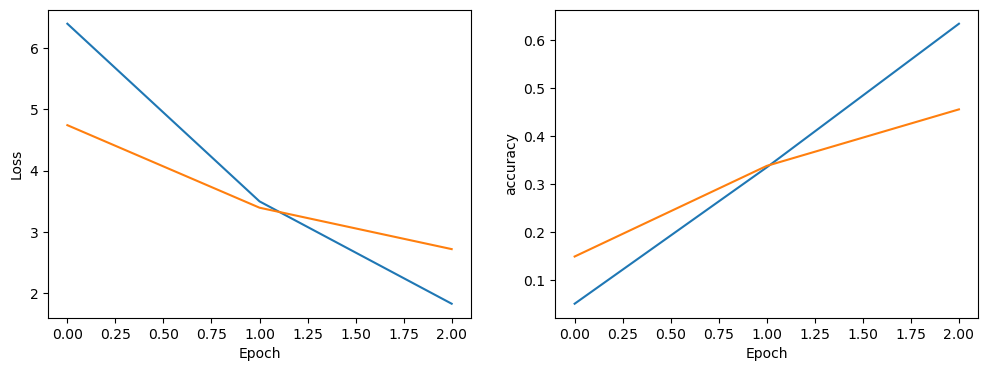

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #3
Train: loss = 0.8108152348692246, accuracy = 0.8509836733248335
Val: loss = 2.4387790116857975, accuracy = 0.5150265957446809


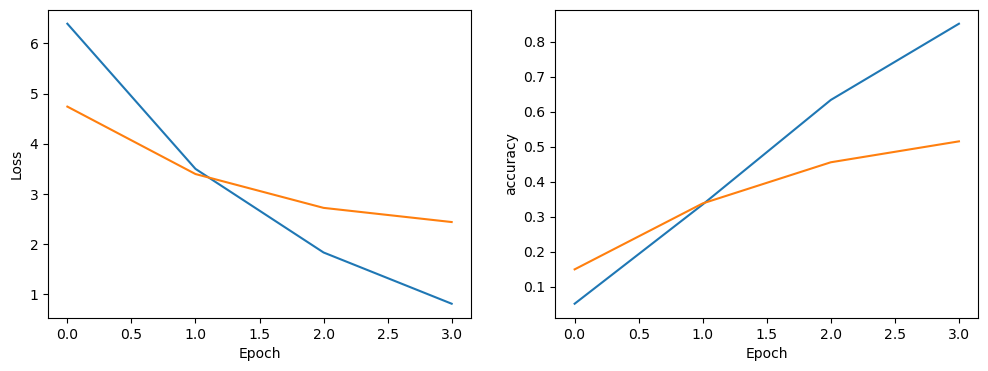

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #4
Train: loss = 0.24433814977084733, accuracy = 0.9703429354370308
Val: loss = 2.3094418074222323, accuracy = 0.54921875


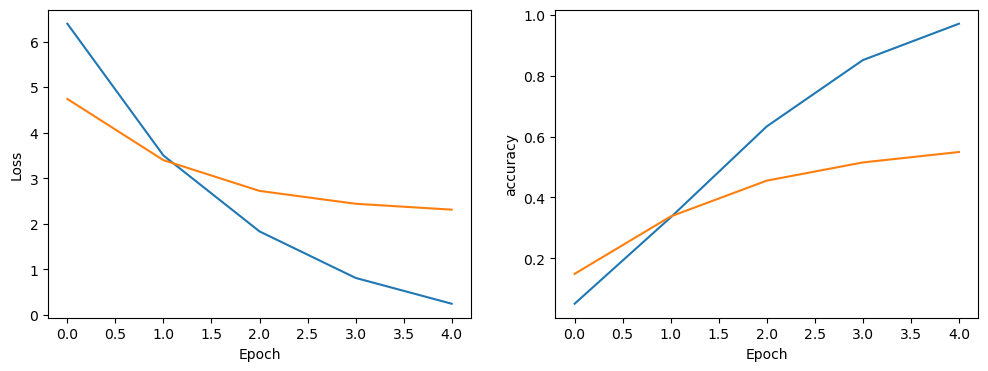

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #5
Train: loss = 0.07443445961078557, accuracy = 0.9930156759101856
Val: loss = 2.135628360383054, accuracy = 0.5892785904255319


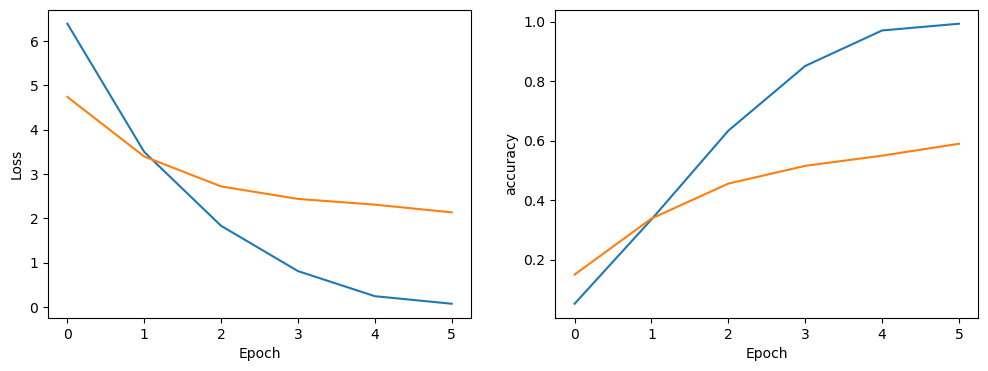

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #6
Train: loss = 0.04060858271974885, accuracy = 0.9946693715469613
Val: loss = 2.1131682116934596, accuracy = 0.5973238031914894


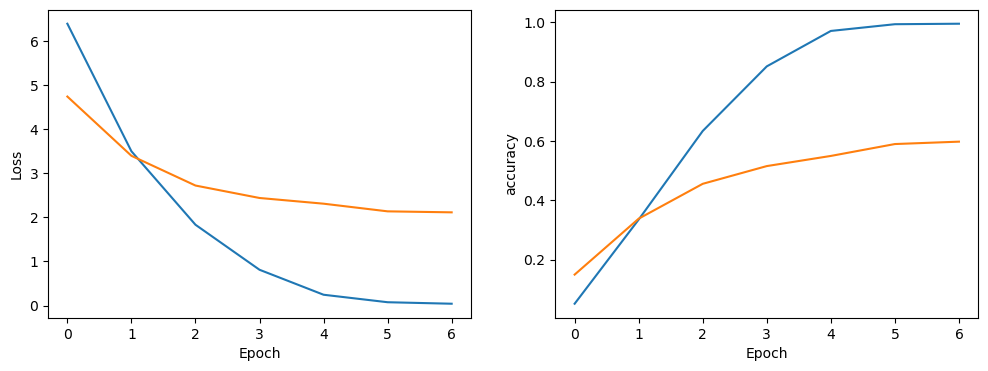

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #7
Train: loss = 0.02680997446549861, accuracy = 0.9965469613259669
Val: loss = 2.1897735063065875, accuracy = 0.5811668882978723


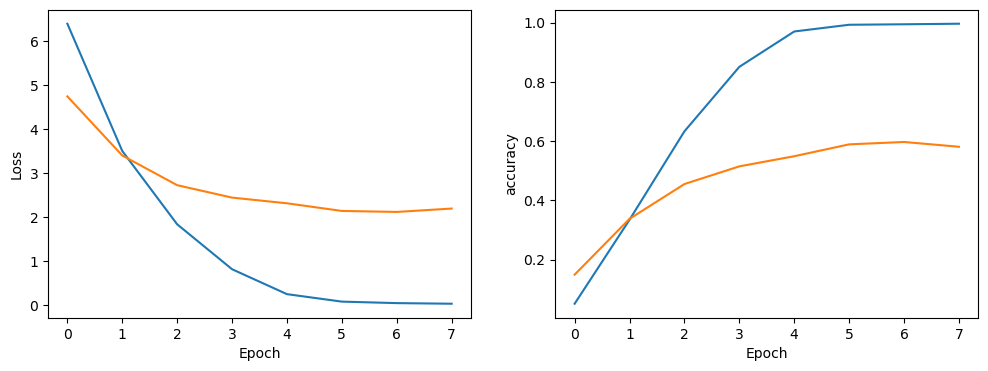

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #8
Train: loss = 0.01971437173344977, accuracy = 0.9975397099447514
Val: loss = 2.1499767176648406, accuracy = 0.5972573138297872


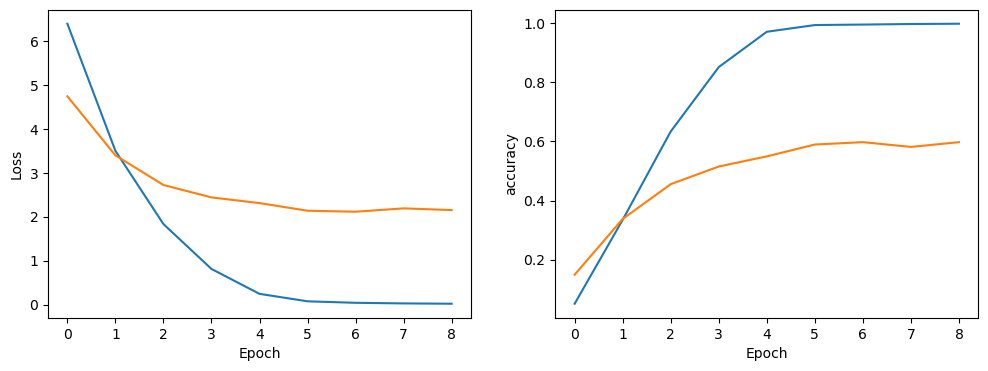

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #9
Train: loss = 0.01690301770673684, accuracy = 0.9976907803867403
Val: loss = 2.150966710232674, accuracy = 0.6037566489361702


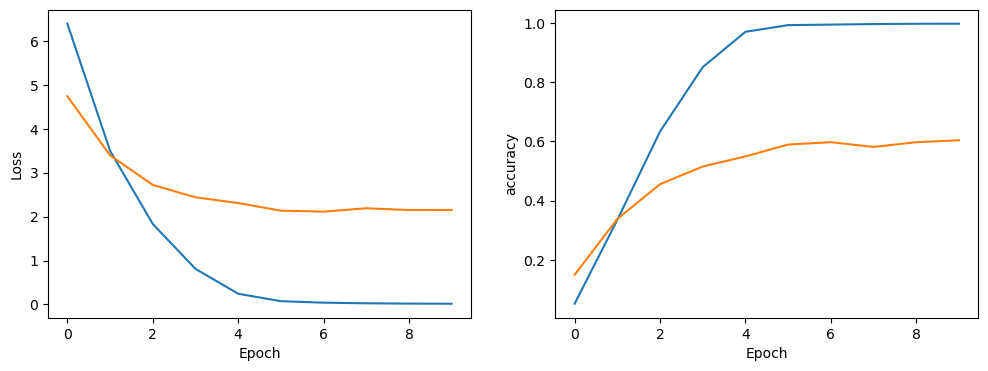

Best epoch = 9, <function accuracy at 0x000002065344B6A0> = 0.6037566489361702


In [34]:
resnet_18, resnet18_stats = train(resnet_18, 10, train_loader, val_loader, optimizer, criterion, accuracy, './models/resnet18_CE', scheduler, '_atempt_3')

<h3>Попытка 4</h3>

Лучше по сравнению с попыткой 1 не стало, попробуем добавить аугментаций

In [35]:
transform=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # нормализация из ImageNet
    ])

train_data = datasets.ImageFolder('../data/celeba/alligned_img25/train', transform)
val_data = datasets.ImageFolder('../data/celeba/alligned_img25/val', transform)

train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
val_loader = DataLoader(val_data, batch_size=256, shuffle=False)

In [36]:
resnet_18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

resnet_18.fc = nn.Linear(resnet_18.fc.in_features, 2000)

for param in resnet_18.parameters():
    param.requires_grad = False

for param in resnet_18.layer4.parameters():
    param.requires_grad = True

for param in resnet_18.fc.parameters():
    param.requires_grad = True

resnet_18 = resnet_18.to(device)

In [37]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([p for p in resnet_18.parameters() if p.requires_grad])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #0
Train: loss = 6.526235651574741, accuracy = 0.03934726501629126
Val: loss = 5.0020526723658785, accuracy = 0.11793550531914894


  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #1
Train: loss = 3.807941592200685, accuracy = 0.2754356141096473
Val: loss = 3.415753648636189, accuracy = 0.32121010638297876


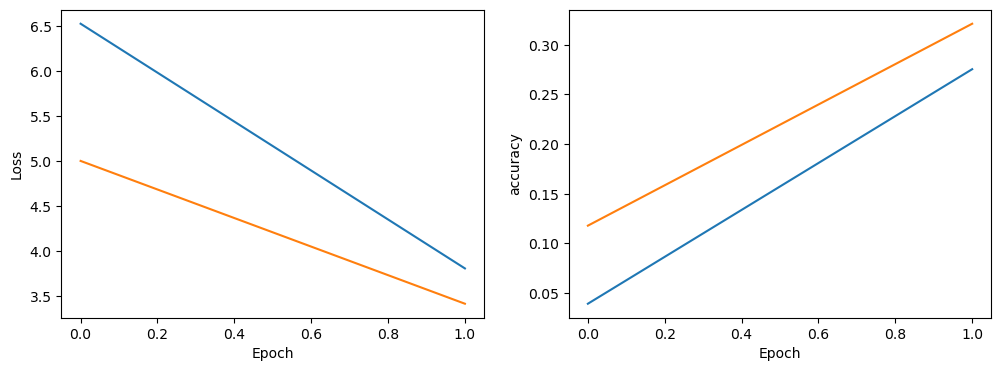

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #2
Train: loss = 2.3636377904955195, accuracy = 0.5172160539736507
Val: loss = 2.753012182864737, accuracy = 0.4426363031914894


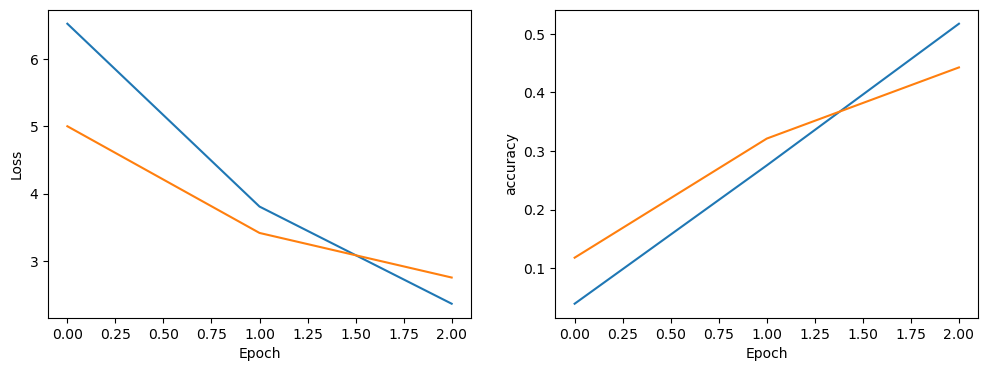

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #3
Train: loss = 1.532764566537425, accuracy = 0.6790760244014733
Val: loss = 2.406463437892021, accuracy = 0.5134973404255319


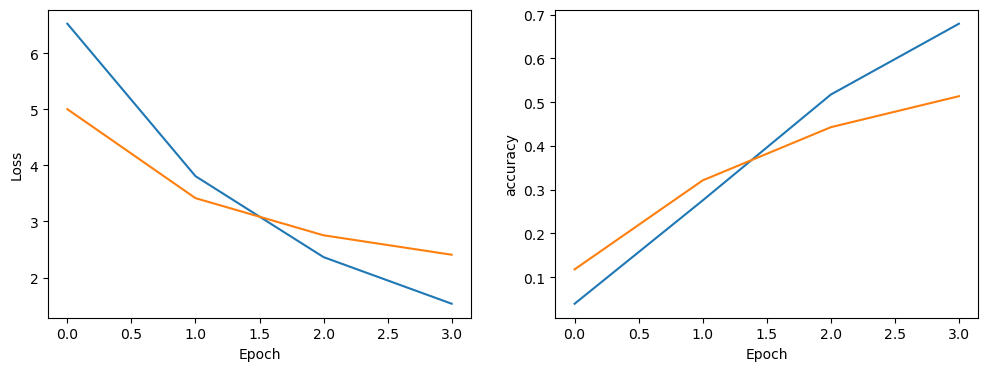

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #4
Train: loss = 1.0248654089579925, accuracy = 0.7815396346862162
Val: loss = 2.3472070389605584, accuracy = 0.5251163563829787


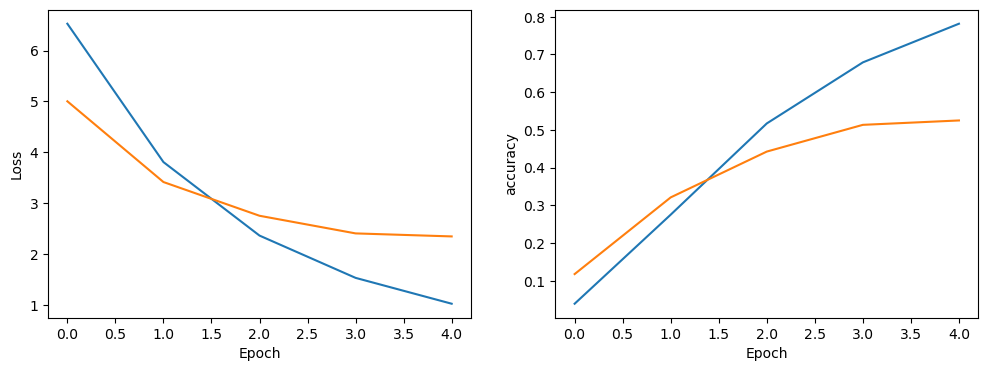

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #5
Train: loss = 0.6813776626442019, accuracy = 0.8571747945884686
Val: loss = 2.138259968859084, accuracy = 0.5720578457446809


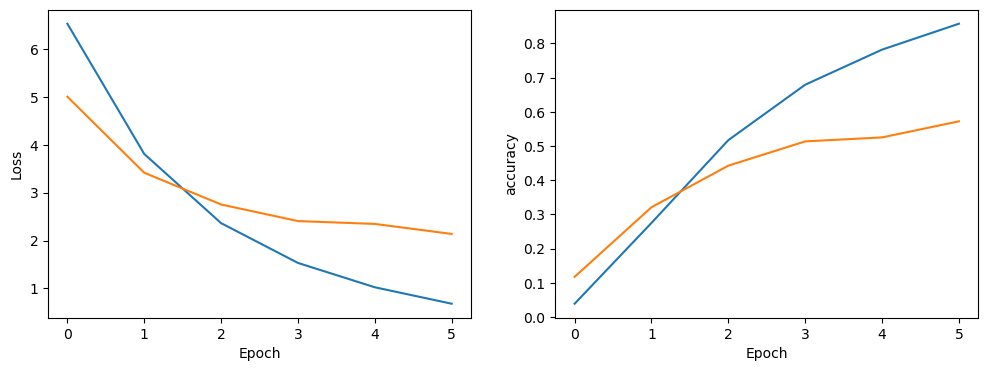

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #6
Train: loss = 0.43839548026000597, accuracy = 0.9116317599872503
Val: loss = 2.152516872324842, accuracy = 0.5829953457446809


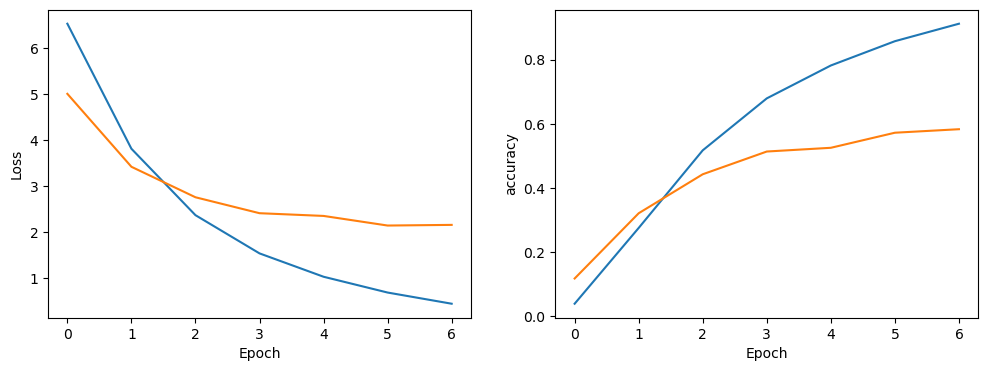

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #7
Train: loss = 0.29625315050393836, accuracy = 0.9405483026986825
Val: loss = 2.13723630854424, accuracy = 0.5888464095744681


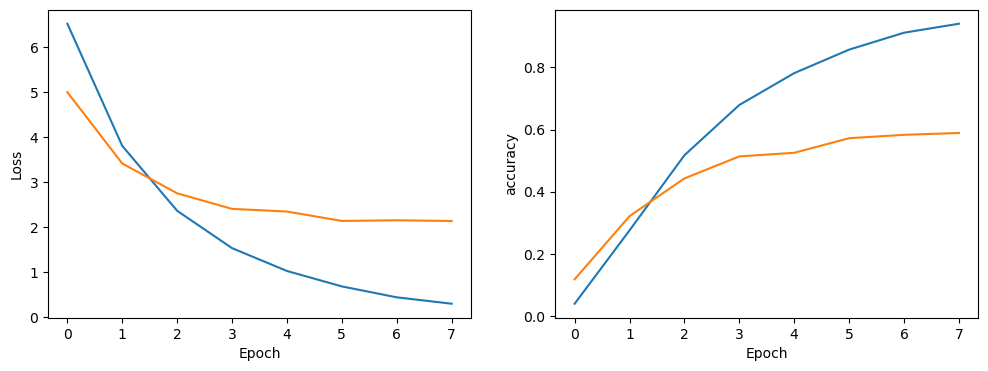

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #8
Train: loss = 0.207622734140296, accuracy = 0.9598395001062473
Val: loss = 2.1037823798808644, accuracy = 0.6057347074468085


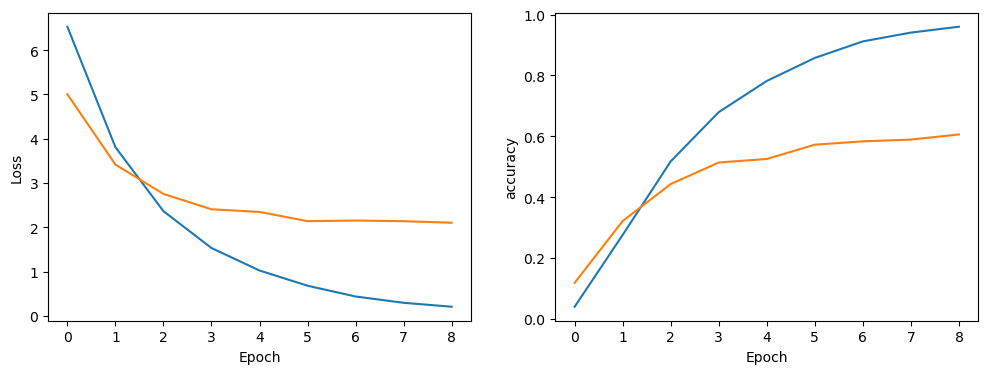

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #9
Train: loss = 0.15360788996871663, accuracy = 0.9707179000212494
Val: loss = 2.1963120851110904, accuracy = 0.5989527925531916


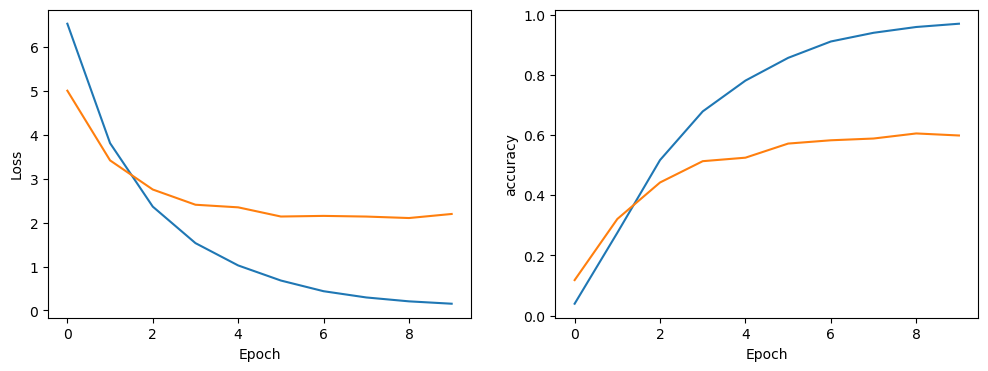

Best epoch = 8, <function accuracy at 0x000002065344B6A0> = 0.6057347074468085


In [38]:
resnet_18, resnet18_stats = train(resnet_18, 10, train_loader, val_loader, optimizer, criterion, accuracy, './models/resnet18_CE', scheduler, '_atempt_4')

<h3>Попытка 5</h3>

Добавим дропаут на последний слой

In [39]:
resnet_18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

resnet_18.fc = nn.Sequential(
    nn.BatchNorm1d(512),  
    nn.Dropout(0.5),
    nn.Linear(512, 2000)
)

for param in resnet_18.parameters():
    param.requires_grad = False

for param in resnet_18.layer4.parameters():
    param.requires_grad = True

for param in resnet_18.fc.parameters():
    param.requires_grad = True

resnet_18 = resnet_18.to(device)

In [40]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([p for p in resnet_18.parameters() if p.requires_grad])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #0
Train: loss = 6.43196884703241, accuracy = 0.042012523905652355
Val: loss = 4.911824652489195, accuracy = 0.15482047872340426


  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #1
Train: loss = 4.053983100870037, accuracy = 0.2596083014591302
Val: loss = 3.3468601906553226, accuracy = 0.3871841755319149


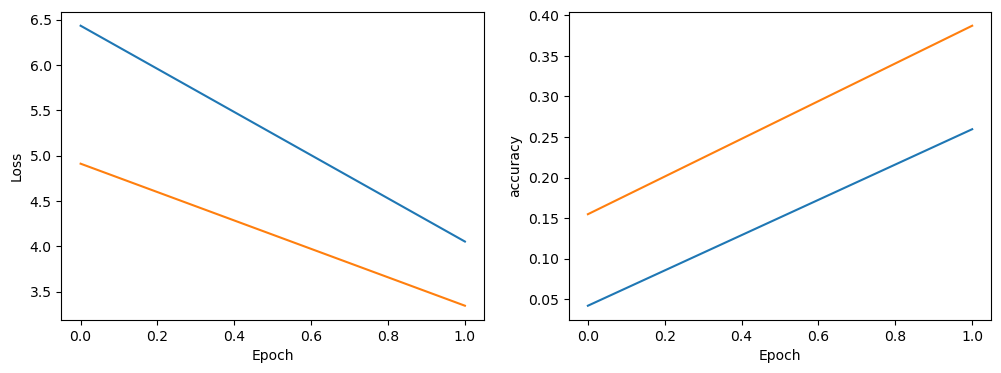

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #2
Train: loss = 2.5706514653579964, accuracy = 0.49522307515228786
Val: loss = 2.526236556945963, accuracy = 0.511186835106383


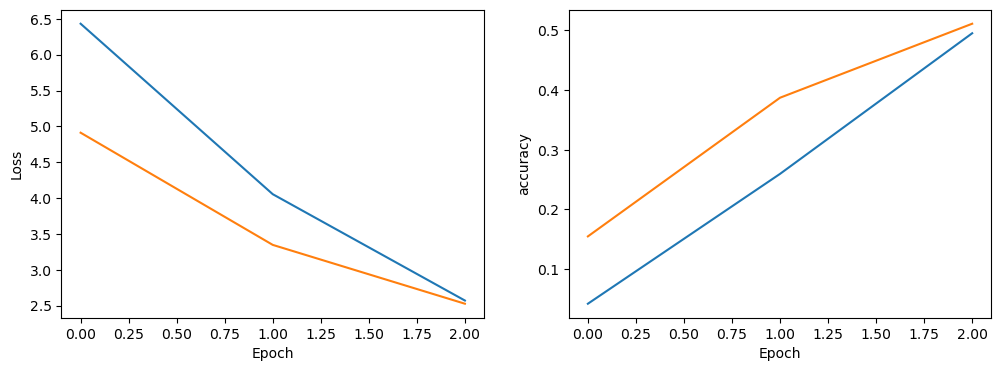

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #3
Train: loss = 1.7412735263287034, accuracy = 0.6402346516857912
Val: loss = 2.1630856813268458, accuracy = 0.569281914893617


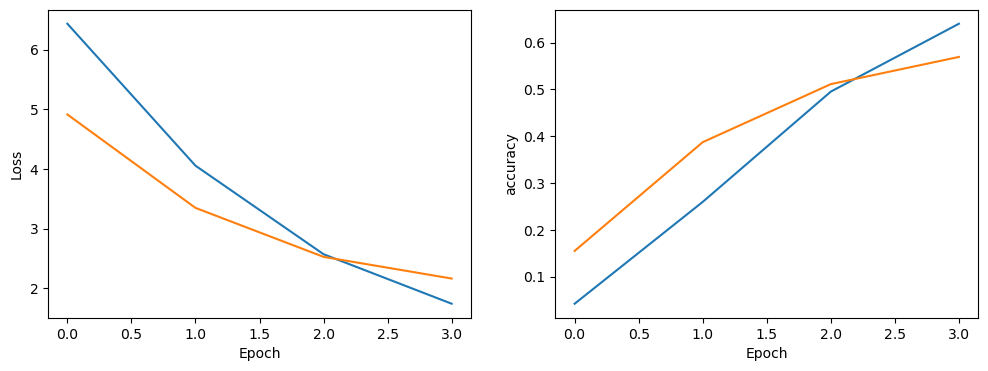

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #4
Train: loss = 1.2367332518430045, accuracy = 0.7347563836945743
Val: loss = 2.009656918809769, accuracy = 0.6066489361702128


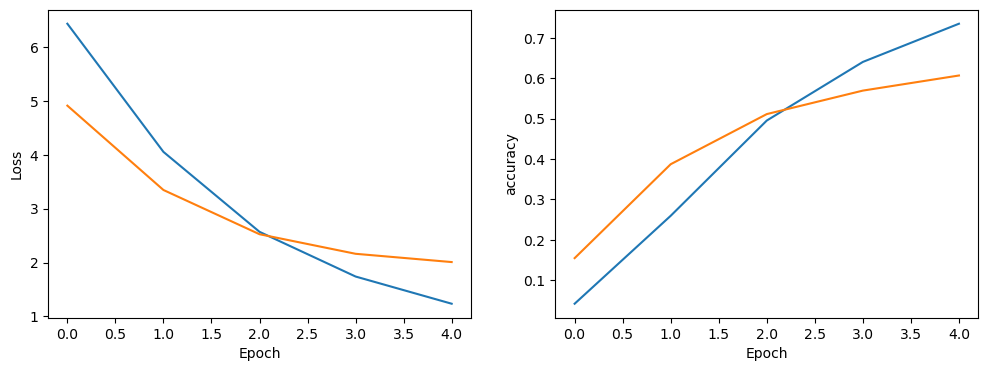

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #5
Train: loss = 0.9005514027664016, accuracy = 0.8018573363790905
Val: loss = 2.0136586630598026, accuracy = 0.60390625


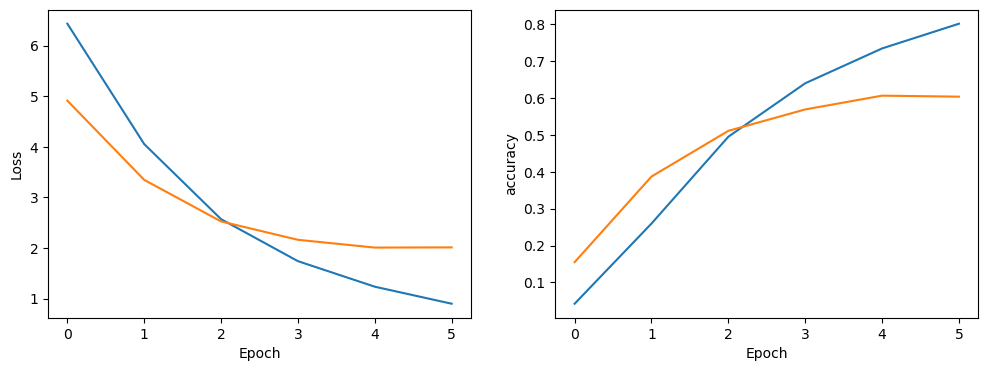

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #6
Train: loss = 0.6665310085807716, accuracy = 0.8487255852457855
Val: loss = 1.8736662027683664, accuracy = 0.6370844414893617


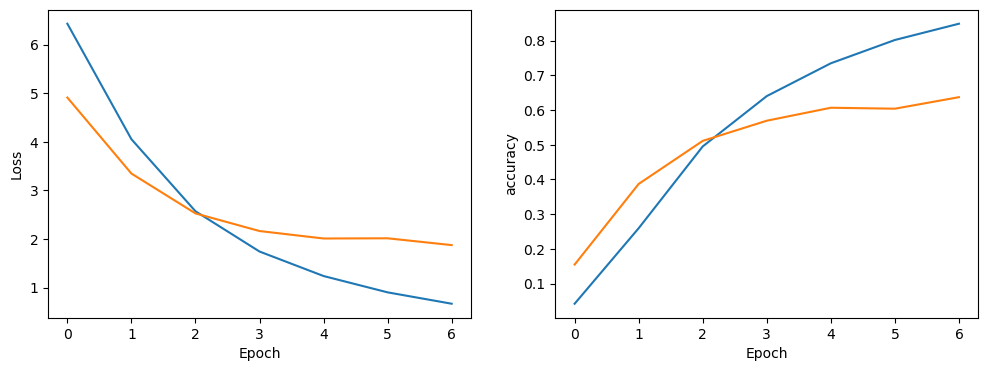

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #7
Train: loss = 0.509563854221481, accuracy = 0.8800903545119706
Val: loss = 1.8720072025948382, accuracy = 0.6464760638297872


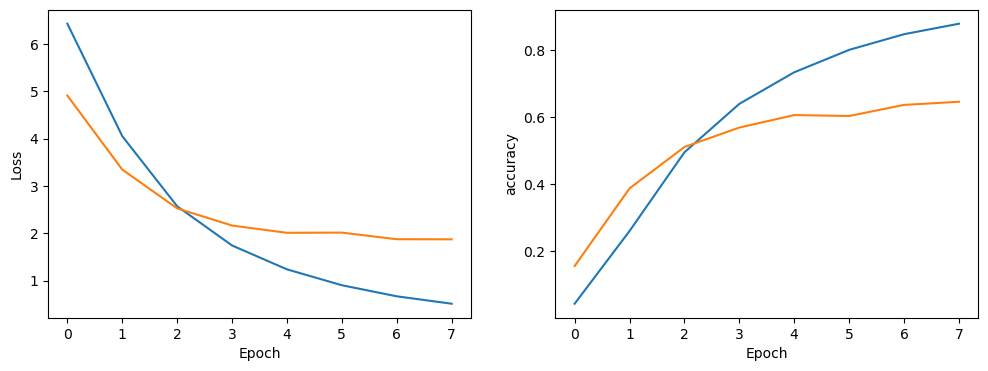

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #8
Train: loss = 0.40960081415611077, accuracy = 0.9007128532724182
Val: loss = 1.89868774058971, accuracy = 0.6405418882978723


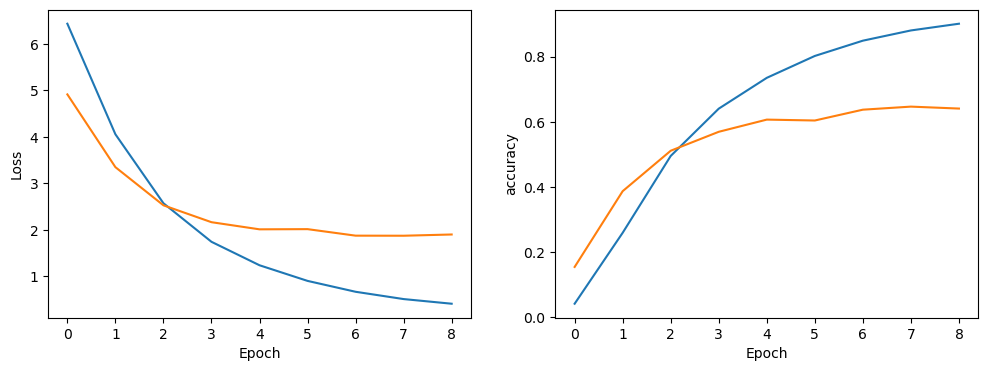

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #9
Train: loss = 0.34364770015300306, accuracy = 0.9148689837441565
Val: loss = 1.919433984350651, accuracy = 0.6486037234042553


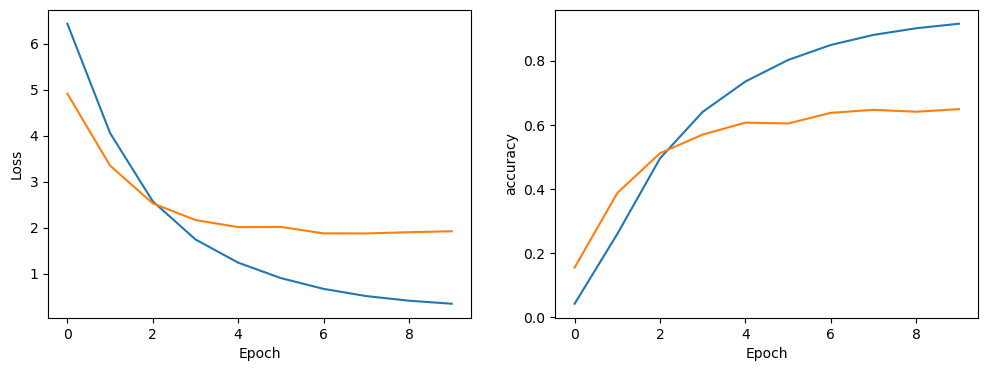

Best epoch = 9, <function accuracy at 0x000002065344B6A0> = 0.6486037234042553


In [41]:
resnet_18, resnet18_stats = train(resnet_18, 10, train_loader, val_loader, optimizer, criterion, accuracy, './models/resnet18_CE', scheduler, '_atempt_5')

Добавилось несколько процентов, но до 0.7 не дотягивает, попробуем разморозить ещё один слой

<h3>Попытка 6</h3>

In [42]:
resnet_18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

resnet_18.fc = nn.Sequential(
    nn.BatchNorm1d(512),  
    nn.Dropout(0.5),
    nn.Linear(512, 2000)
)

for param in resnet_18.parameters():
    param.requires_grad = False

for param in resnet_18.layer3.parameters():
    param.requires_grad = True

for param in resnet_18.layer4.parameters():
    param.requires_grad = True

for param in resnet_18.fc.parameters():
    param.requires_grad = True

resnet_18 = resnet_18.to(device)

In [43]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([p for p in resnet_18.parameters() if p.requires_grad])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #0
Train: loss = 6.355155849983679, accuracy = 0.04496653208669783
Val: loss = 4.7863849477565035, accuracy = 0.16537566489361702


  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #1
Train: loss = 3.820871635036574, accuracy = 0.28703029820087833
Val: loss = 3.058488886407081, accuracy = 0.4196808510638298


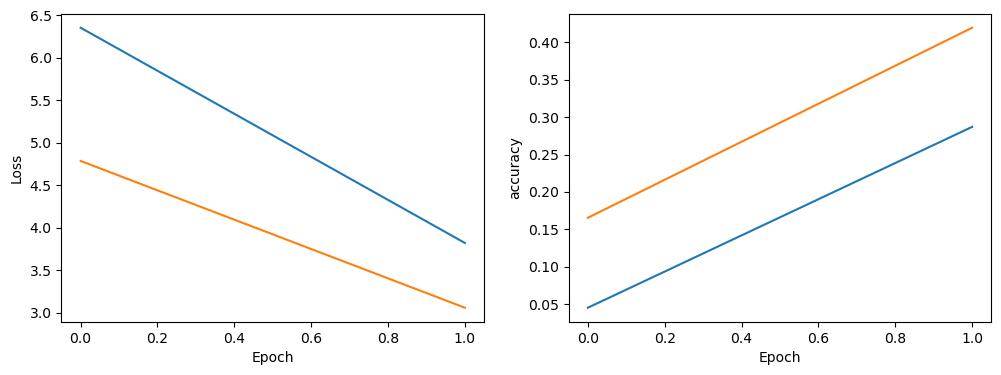

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #2
Train: loss = 2.2896657286427957, accuracy = 0.5419957014095481
Val: loss = 2.266051657656406, accuracy = 0.54765625


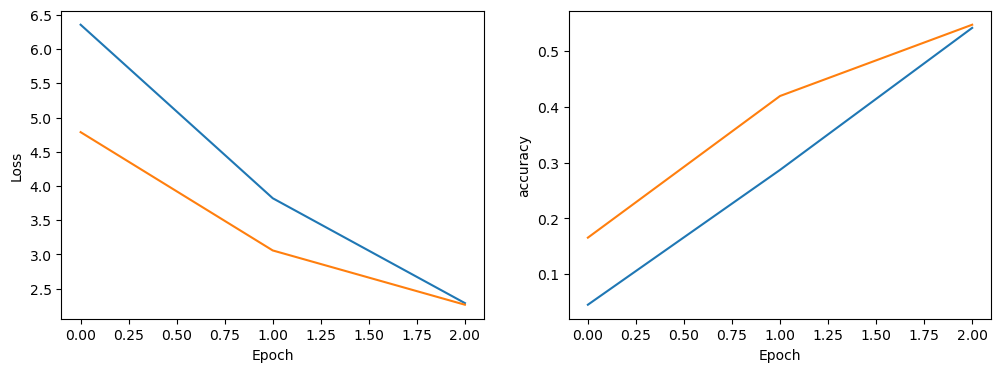

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #3
Train: loss = 1.4822728337503928, accuracy = 0.6959555177787222
Val: loss = 1.8075130264809791, accuracy = 0.6394614361702128


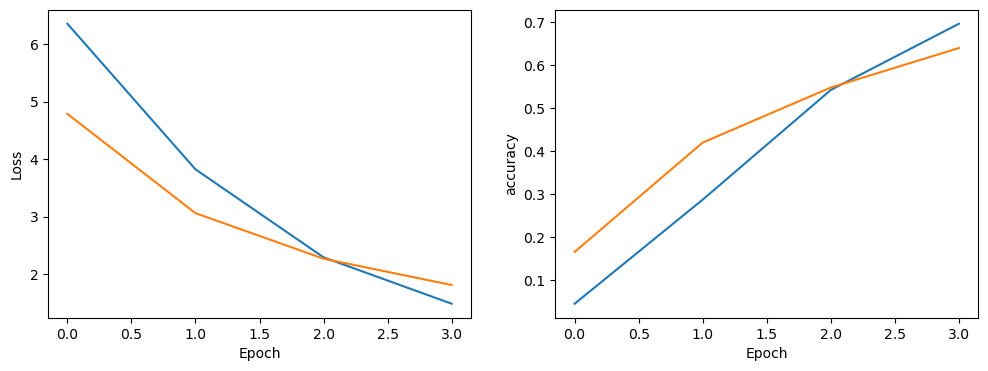

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #4
Train: loss = 1.0177591973246791, accuracy = 0.7818242890281909
Val: loss = 1.7172665139462084, accuracy = 0.6542054521276596


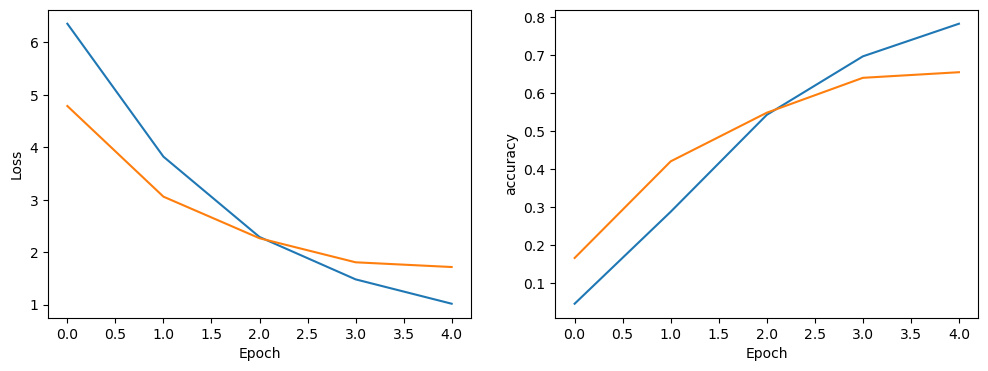

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #5
Train: loss = 0.7311182669183826, accuracy = 0.8404073036194928
Val: loss = 1.6404958506847949, accuracy = 0.6753656914893617


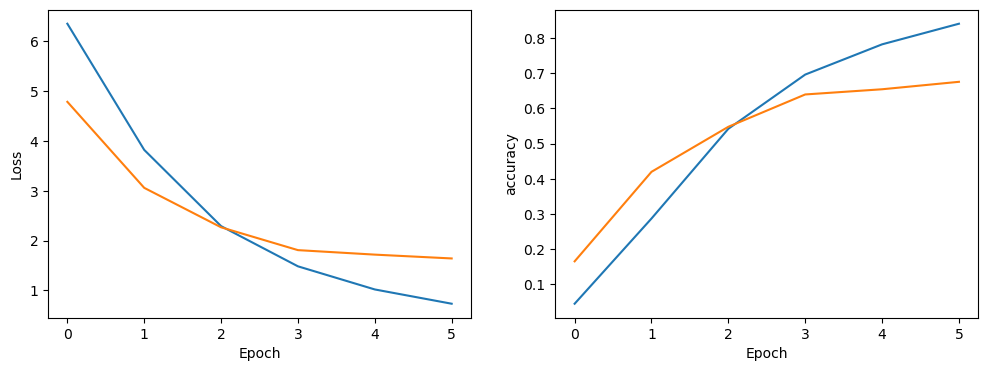

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #6
Train: loss = 0.5359104163738904, accuracy = 0.8806811340133163
Val: loss = 1.5203316668246656, accuracy = 0.7013962765957448


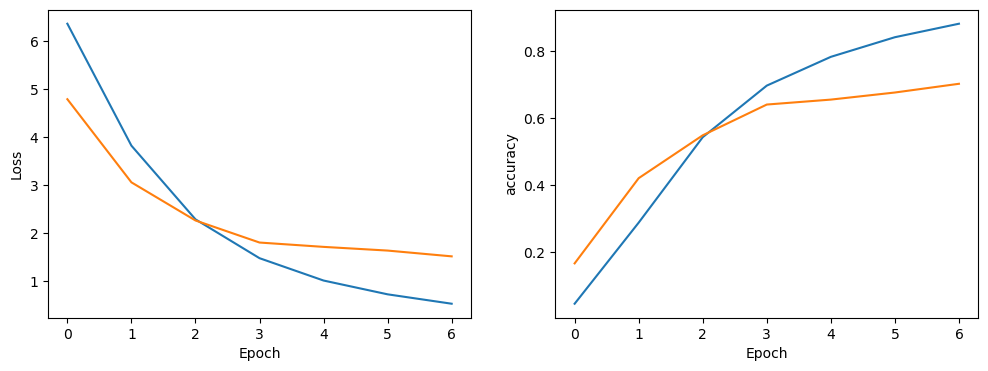

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #7
Train: loss = 0.41717292582461846, accuracy = 0.9049064137979883
Val: loss = 1.5361564996394705, accuracy = 0.7052859042553191


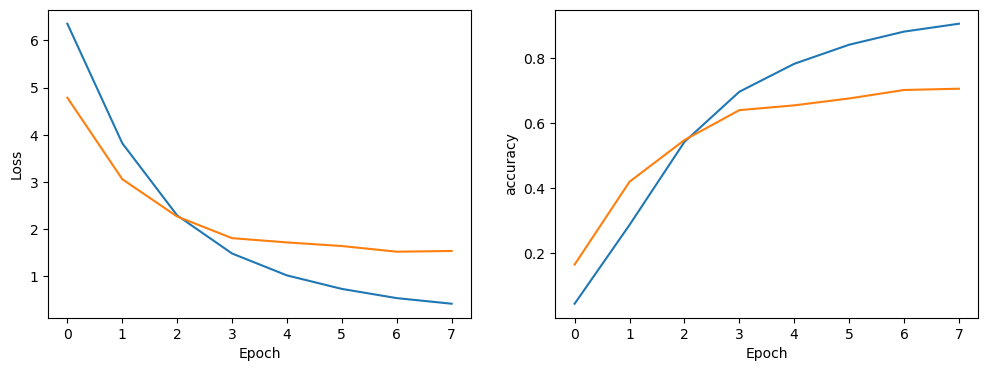

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #8
Train: loss = 0.3206804846696432, accuracy = 0.9249098004320725
Val: loss = 1.5303880940092371, accuracy = 0.7091090425531915


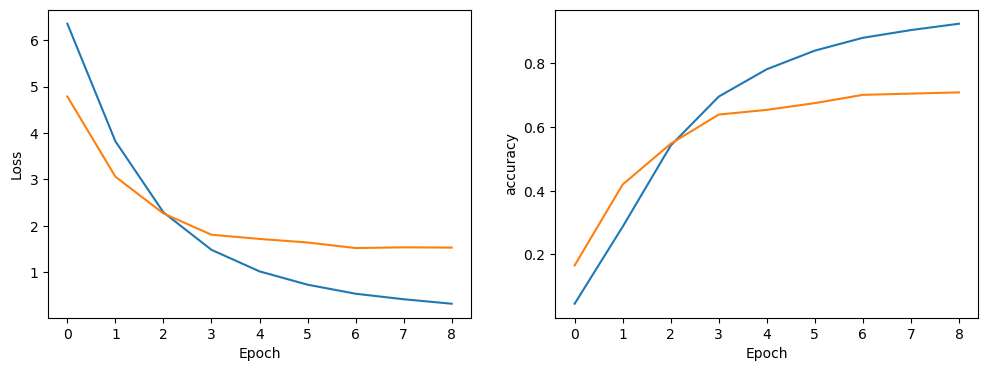

  0%|          | 0/181 [00:00<?, ?it/s]

Epoch #9
Train: loss = 0.2607351174341381, accuracy = 0.9372031714832129
Val: loss = 1.5343123408074075, accuracy = 0.7159242021276596


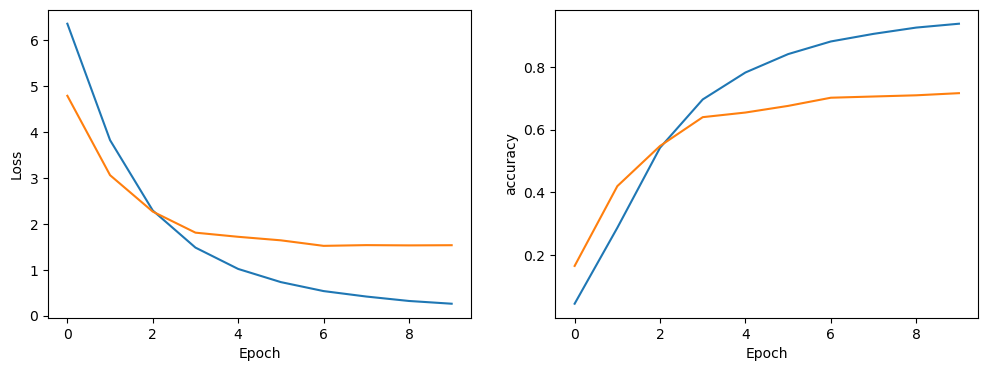

Best epoch = 9, <function accuracy at 0x000002065344B6A0> = 0.7159242021276596


In [44]:
resnet_18, resnet18_stats = train(resnet_18, 10, train_loader, val_loader, optimizer, criterion, accuracy, './models/resnet18_CE', scheduler, '_atempt_6')

Ура, accuracy 0.7 достигнута, попробуем ещё улучшить

<h3>Попытка 7</h3>

Гипотеза - слишком много классов и слишком мало экземпляров в каждом классе, надо или уменьшить количество классов, или увеличить количество фото каждого человека, или же возможно стоит попробовать модель попроще

Также уменьшим batch size

In [45]:
identities_dict =  defaultdict(list)

with open('../data/celeba/Anno/identity_CelebA.txt', 'r') as file:
    for line in file:
        image_name, id = line.strip().split()
        identities_dict[int(id)].append(image_name)

identities_dict = {id: images for id, images in identities_dict.items() if len(images) >= 30}

print(len(identities_dict))

2360


In [46]:
random.seed(42)
all_identities = list(identities_dict.keys())
random.shuffle(all_identities)

train_val_id = all_identities[:1000]
query_id = all_identities[1000:1100]
distractor_id = all_identities[1100:1600]

In [47]:
os.makedirs('../data/celeba/alligned_img_30_1000/', exist_ok=True)

In [48]:
# for id in train_val_id:
#     images = identities_dict[id]
#     train_img, val_img = train_test_split(images, test_size=0.2, random_state=42)
#     train_path = f'../data/celeba/alligned_img_30_1000/train/{id}'
#     val_path =f'../data/celeba/alligned_img_30_1000/val/{id}'
#     os.makedirs(train_path, exist_ok=True)
#     os.makedirs(val_path, exist_ok=True)

#     save_class(train_img, train_path)
#     save_class(val_img, val_path)

In [49]:
transform=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # нормализация из ImageNet
    ])

train_data = datasets.ImageFolder('../data/celeba/alligned_img_30_1000/train', transform)
val_data = datasets.ImageFolder('../data/celeba/alligned_img_30_1000/val', transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)

In [50]:
resnet_18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

resnet_18.fc = nn.Sequential(
    nn.BatchNorm1d(512),  
    nn.Dropout(0.5),
    nn.Linear(512, 1000)
)

for param in resnet_18.parameters():
    param.requires_grad = False

for param in resnet_18.layer3.parameters():
    param.requires_grad = True

for param in resnet_18.layer4.parameters():
    param.requires_grad = True

for param in resnet_18.fc.parameters():
    param.requires_grad = True

resnet_18 = resnet_18.to(device)

In [51]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([p for p in resnet_18.parameters() if p.requires_grad])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #0
Train: loss = 5.71575544489191, accuracy = 0.06003555735430157
Val: loss = 4.276017112934843, accuracy = 0.2092837179949513


  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #1
Train: loss = 3.3720226097614208, accuracy = 0.32891215213536845
Val: loss = 2.823055150661063, accuracy = 0.4305721465921385


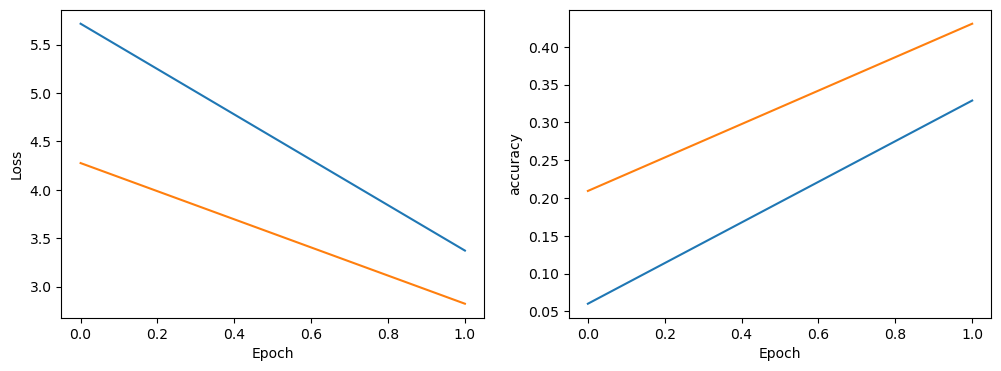

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #2
Train: loss = 1.9792747250262728, accuracy = 0.5877677642229417
Val: loss = 1.9965411500727877, accuracy = 0.5771332942661378


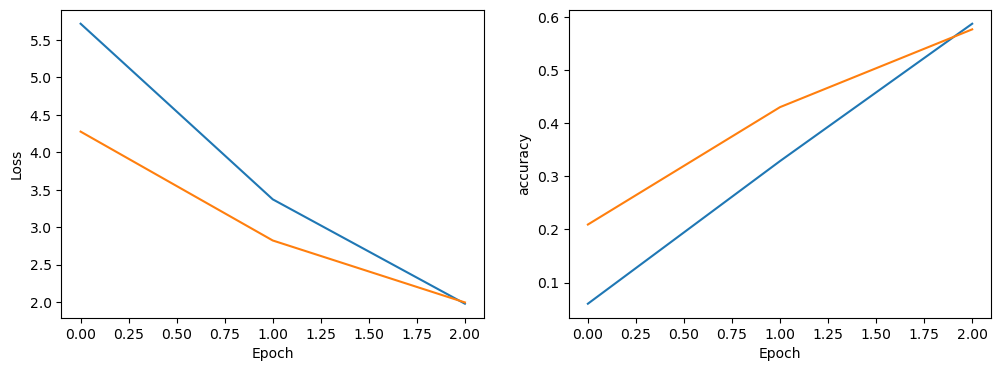

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #3
Train: loss = 1.2462583865891113, accuracy = 0.73120049433395
Val: loss = 1.6109864813216188, accuracy = 0.6594420528308691


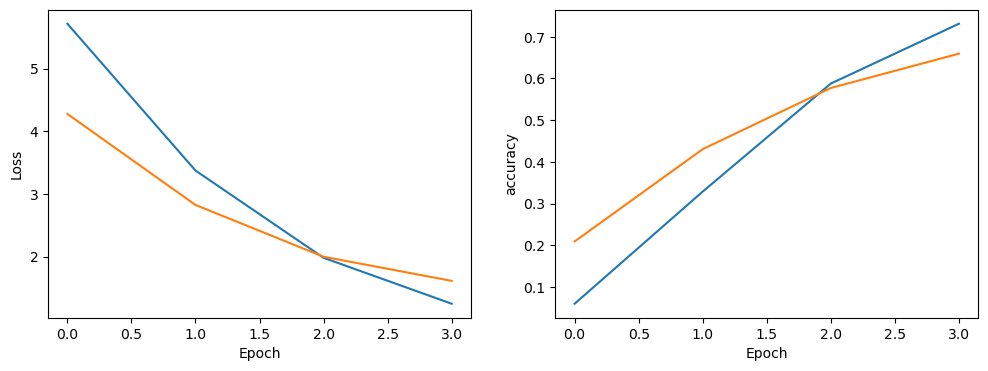

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #4
Train: loss = 0.84214367796766, accuracy = 0.8124891593432008
Val: loss = 1.7295789084535964, accuracy = 0.6320405472412549


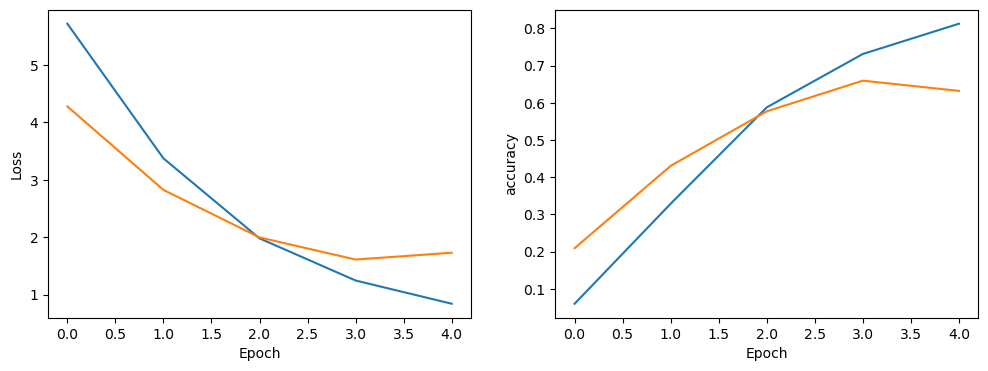

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #5
Train: loss = 0.5835917542906518, accuracy = 0.8668147018578477
Val: loss = 1.3966883065852713, accuracy = 0.7071904300396683


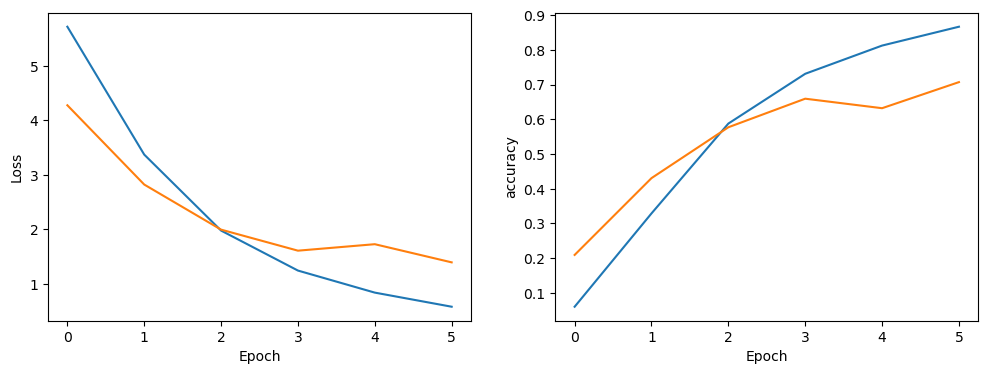

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #6
Train: loss = 0.40264536900089143, accuracy = 0.9070642537773667
Val: loss = 1.4138113044677896, accuracy = 0.7070805535521097


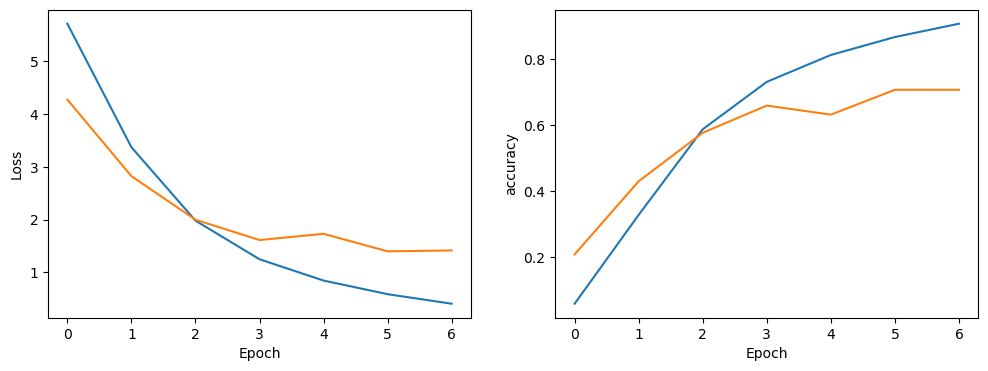

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #7
Train: loss = 0.30291330251604953, accuracy = 0.9299904361316682
Val: loss = 1.36738058607629, accuracy = 0.7257680084745763


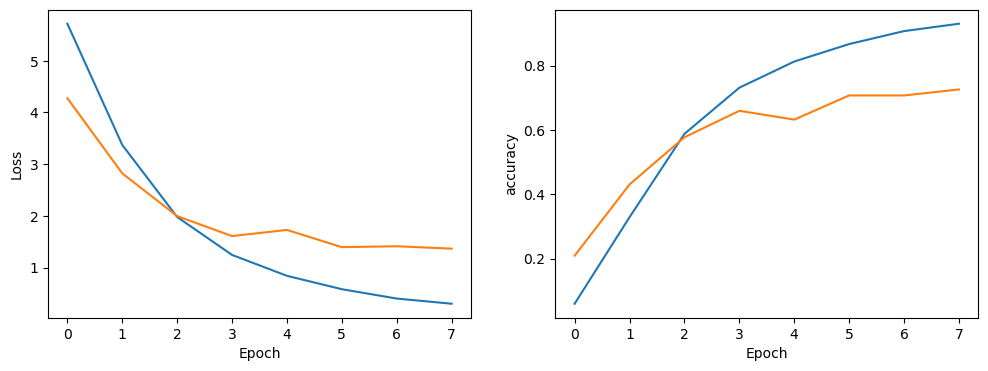

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #8
Train: loss = 0.2317916997807457, accuracy = 0.9439598269349369
Val: loss = 1.4413315438209695, accuracy = 0.7161129642985935


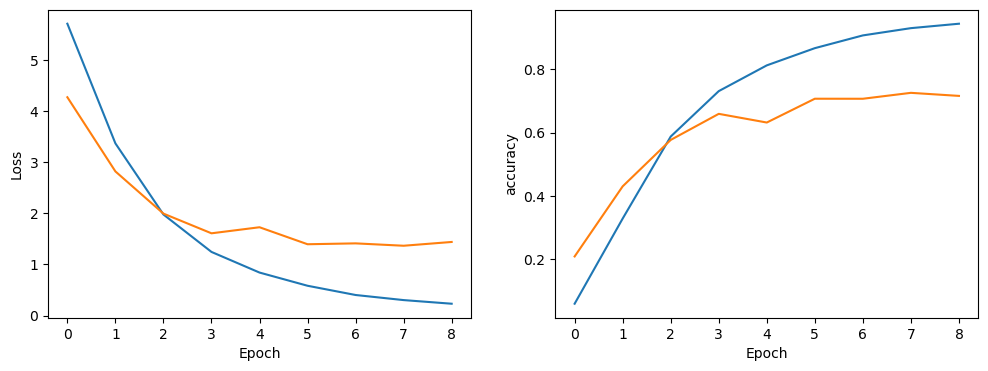

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #9
Train: loss = 0.18639448954862484, accuracy = 0.9541819640379279
Val: loss = 1.4070341168565954, accuracy = 0.7233563604399567


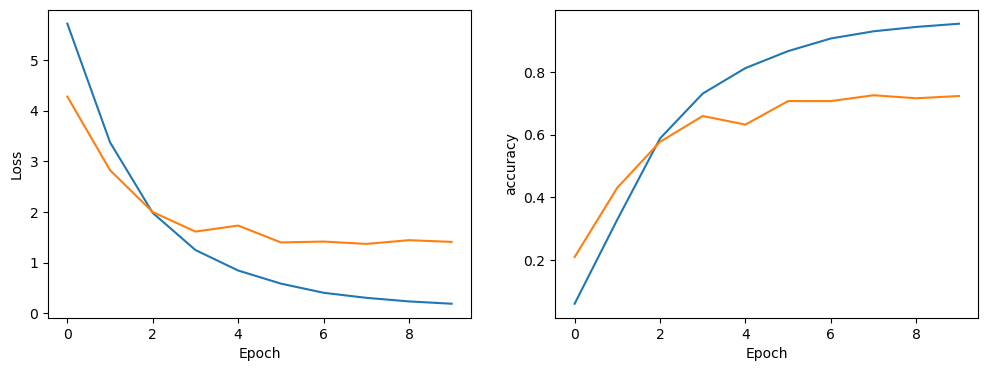

Best epoch = 7, <function accuracy at 0x000002065344B6A0> = 0.7257680084745763


In [52]:
resnet_18, resnet18_stats = train(resnet_18, 10, train_loader, val_loader, optimizer, criterion, accuracy, './models/resnet18_CE', scheduler, '_atempt_7')

Нормально в принципе


<h2>ResNet50</h2>

Используем улучшения, которые помогли resnet 18 (батчнорм, количество классов 1000) на resnet 50

<h3>Попытка 1</h3>

In [53]:
resnet_50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

resnet_50.fc = nn.Sequential(
    nn.BatchNorm1d(2048),  
    nn.Dropout(0.5),
    nn.Linear(2048, 1000)
)

for param in resnet_50.parameters():
    param.requires_grad = False

for param in resnet_50.layer3.parameters():
    param.requires_grad = True

for param in resnet_50.layer4.parameters():
    param.requires_grad = True

for param in resnet_50.fc.parameters():
    param.requires_grad = True

resnet_50 = resnet_50.to(device)

In [54]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([p for p in resnet_50.parameters() if p.requires_grad])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #0
Train: loss = 5.587383440200319, accuracy = 0.06959340309898242
Val: loss = 4.92625726030228, accuracy = 0.11669446447890372


  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #1
Train: loss = 3.1392671947783612, accuracy = 0.3358700470243602
Val: loss = 2.923116125959031, accuracy = 0.3906926163000361


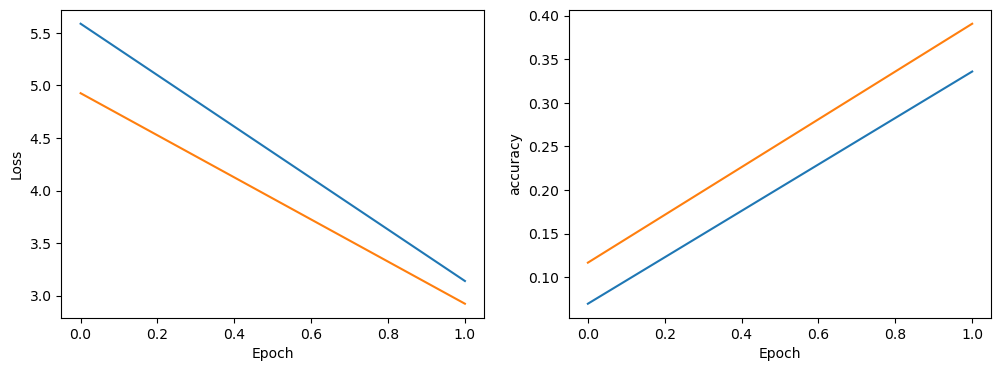

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #2
Train: loss = 1.8244581121079466, accuracy = 0.5850672361625038
Val: loss = 2.087408387914617, accuracy = 0.5481259015506672


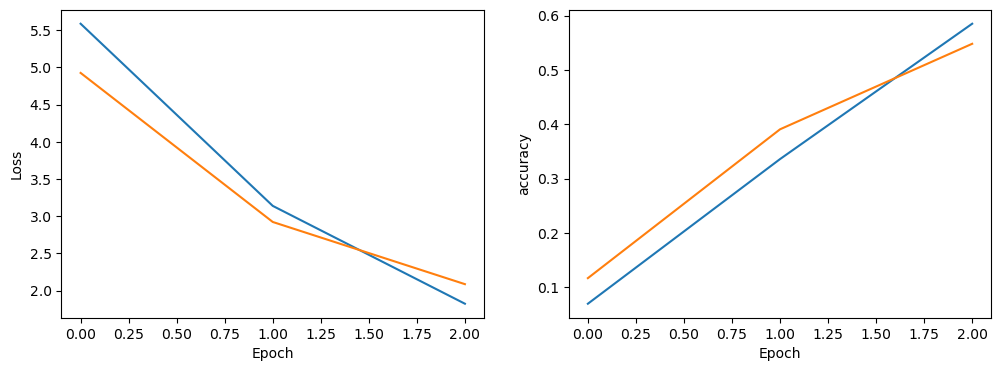

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #3
Train: loss = 1.0851042397478794, accuracy = 0.7453234611085415
Val: loss = 1.6940977903122598, accuracy = 0.6439410160476019


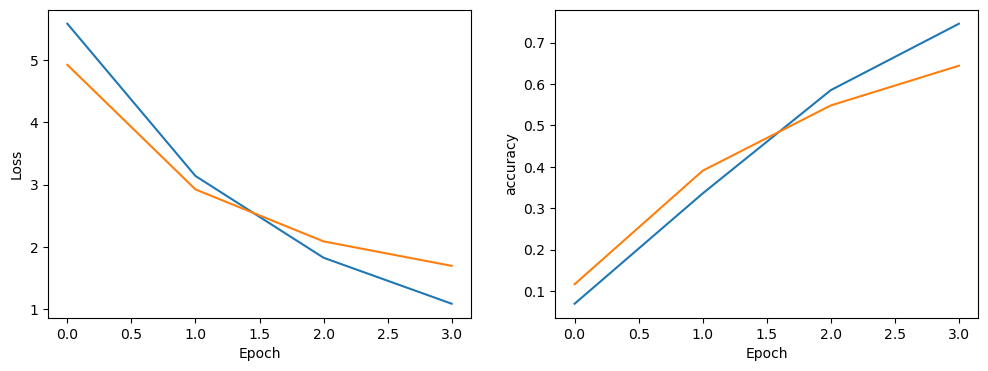

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #4
Train: loss = 0.6894964475898032, accuracy = 0.8342288920366945
Val: loss = 1.7067387256216495, accuracy = 0.6502293319509556


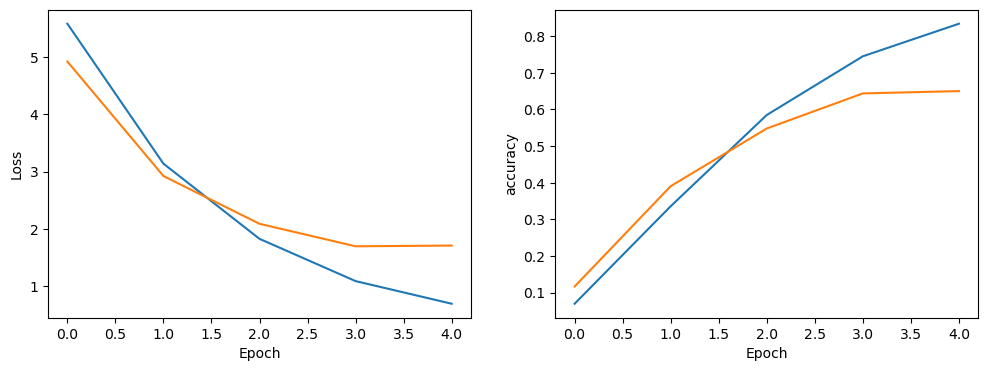

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #5
Train: loss = 0.4393120041077441, accuracy = 0.8909526287388221
Val: loss = 1.476676491980857, accuracy = 0.7052661828344753


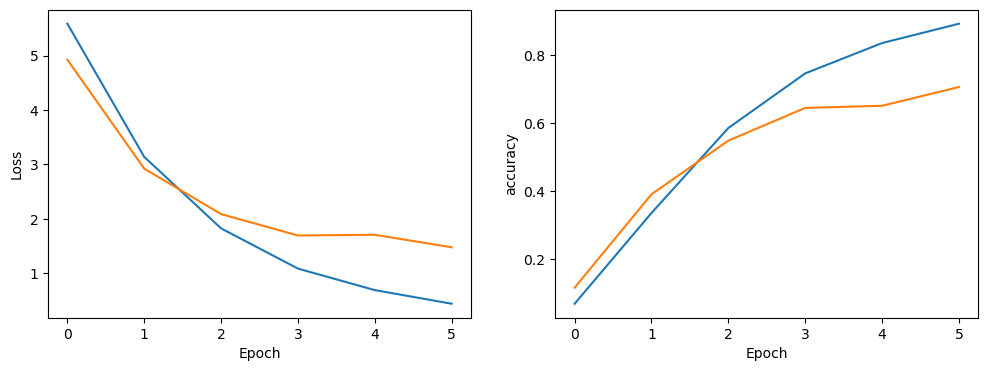

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #6
Train: loss = 0.28569892865229163, accuracy = 0.928310736586494
Val: loss = 1.4611625950387184, accuracy = 0.7184119184998197


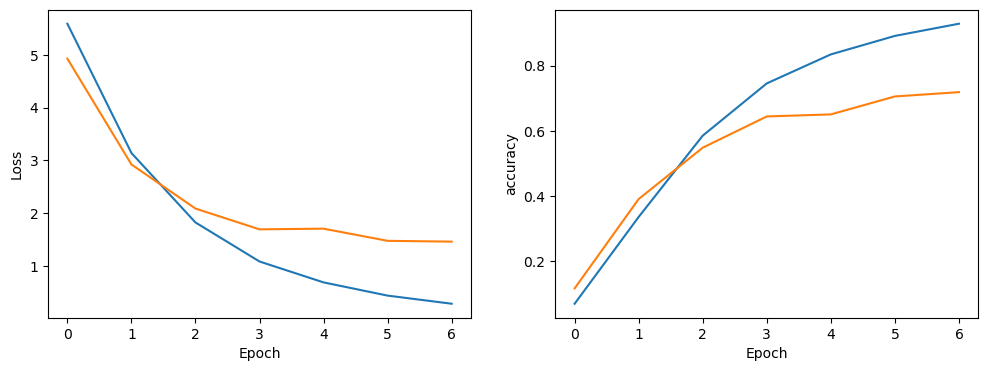

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #7
Train: loss = 0.21321935396879277, accuracy = 0.943437066373728
Val: loss = 1.446914883370095, accuracy = 0.7315858276235124


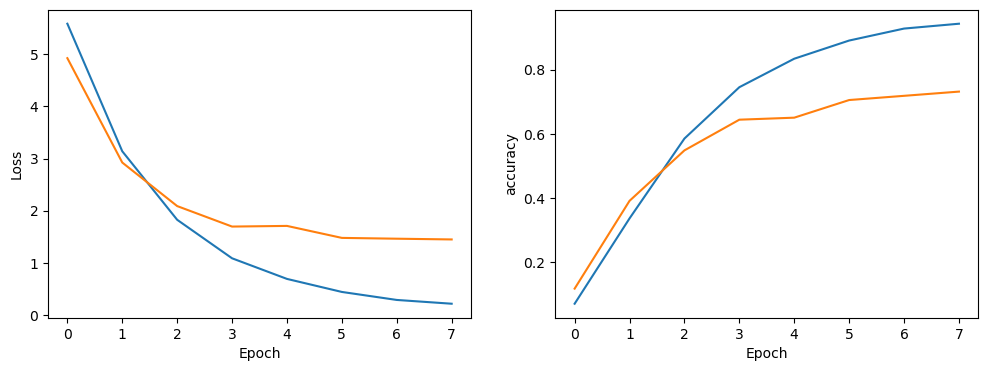

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #8
Train: loss = 0.1624902193731767, accuracy = 0.9579400583950046
Val: loss = 1.532317299792107, accuracy = 0.725241164803462


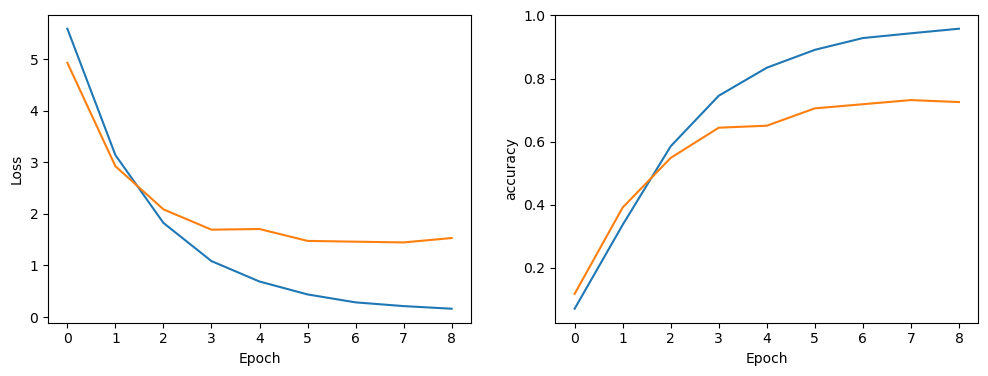

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #9
Train: loss = 0.16155280610744624, accuracy = 0.9556665317607155
Val: loss = 1.4621958402877158, accuracy = 0.7331353678326722


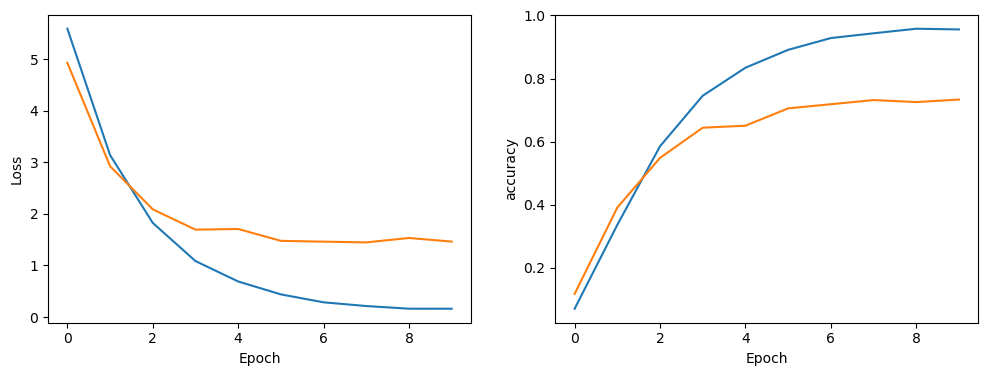

Best epoch = 9, <function accuracy at 0x000002065344B6A0> = 0.7331353678326722


In [55]:
resnet_50, resnet50_stats = train(resnet_50, 10, train_loader, val_loader, optimizer, criterion, accuracy, './models/resnet50_CE', scheduler, '_atempt_1')

<h3>Попытка 2</h3>

Разморозим ещё один слой

In [56]:
resnet_50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

resnet_50.fc = nn.Sequential(
    nn.BatchNorm1d(2048),  
    nn.Dropout(0.5),
    nn.Linear(2048, 1000)
)

for param in resnet_50.parameters():
    param.requires_grad = False

for param in resnet_50.layer2.parameters():
    param.requires_grad = True

for param in resnet_50.layer3.parameters():
    param.requires_grad = True

for param in resnet_50.layer4.parameters():
    param.requires_grad = True

for param in resnet_50.fc.parameters():
    param.requires_grad = True

resnet_50 = resnet_50.to(device)

In [57]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([p for p in resnet_50.parameters() if p.requires_grad])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #0
Train: loss = 5.917951358125565, accuracy = 0.05094084855843355
Val: loss = 4.828134303397321, accuracy = 0.12122475658131987


  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #1
Train: loss = 3.599569361260597, accuracy = 0.2694818647856923
Val: loss = 3.825911648730014, accuracy = 0.26175396682293545


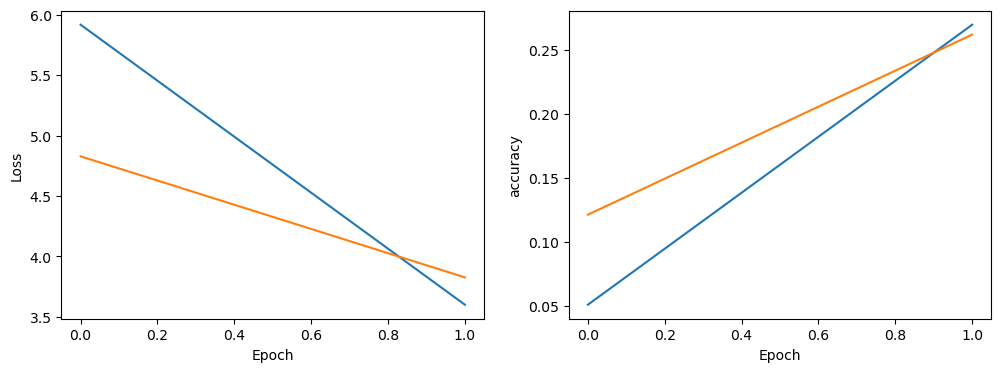

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #2
Train: loss = 2.249596318031879, accuracy = 0.5026559609158187
Val: loss = 2.3547410685965358, accuracy = 0.5039358321312658


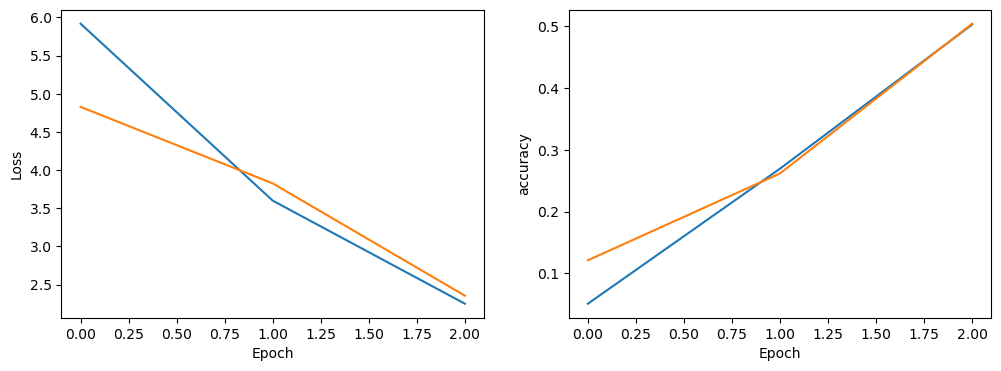

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #3
Train: loss = 1.4489312511175236, accuracy = 0.6672165288698736
Val: loss = 1.9521516079598284, accuracy = 0.596291245943022


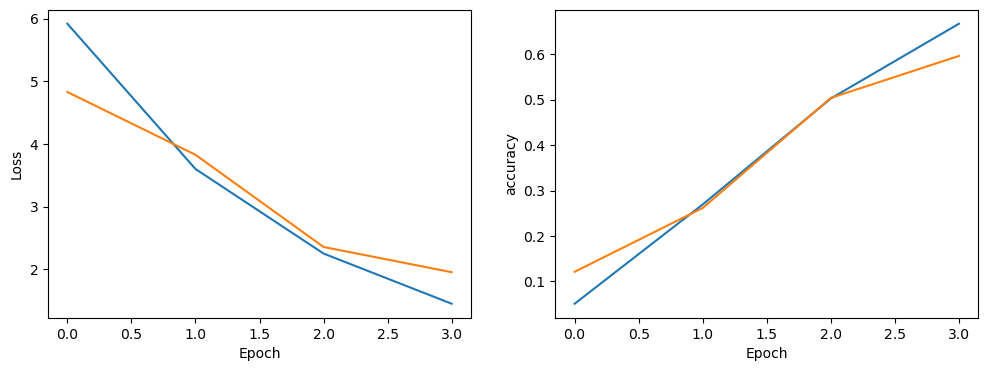

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #4
Train: loss = 0.9555369371429403, accuracy = 0.7766505502235586
Val: loss = 1.8194032349485032, accuracy = 0.6300064235485034


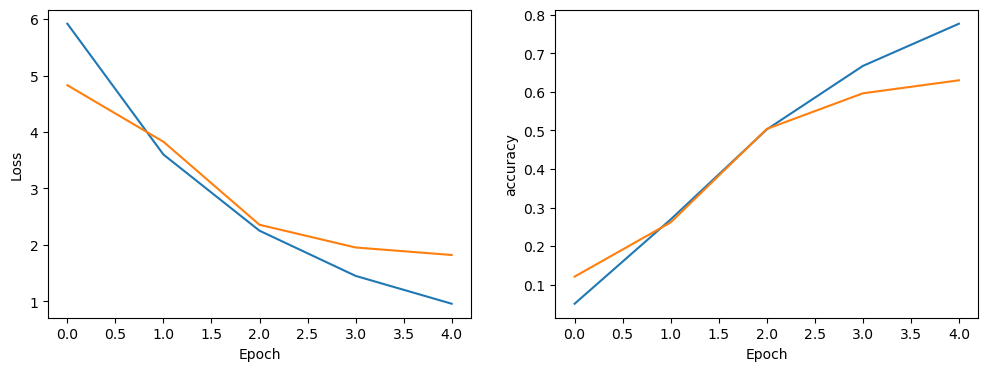

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #5
Train: loss = 0.6513930917420285, accuracy = 0.8410862097209374
Val: loss = 1.7661541776454195, accuracy = 0.6552582942661378


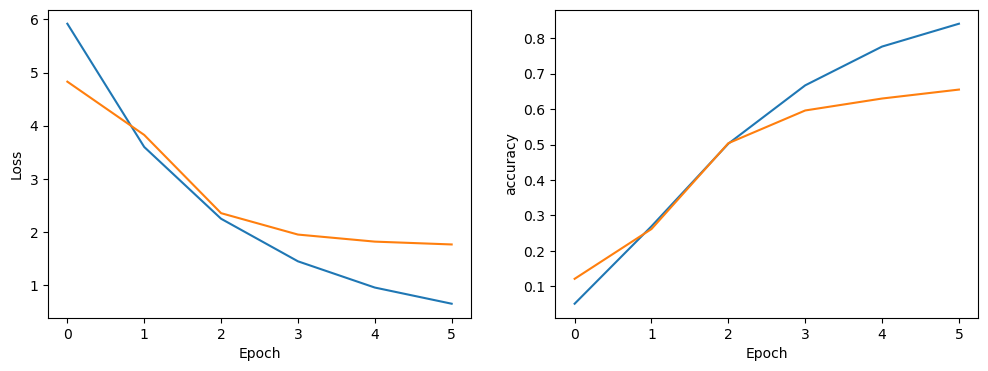

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #6
Train: loss = 0.4279346001592088, accuracy = 0.8919138336416899
Val: loss = 1.5550311321907855, accuracy = 0.6963436485755499


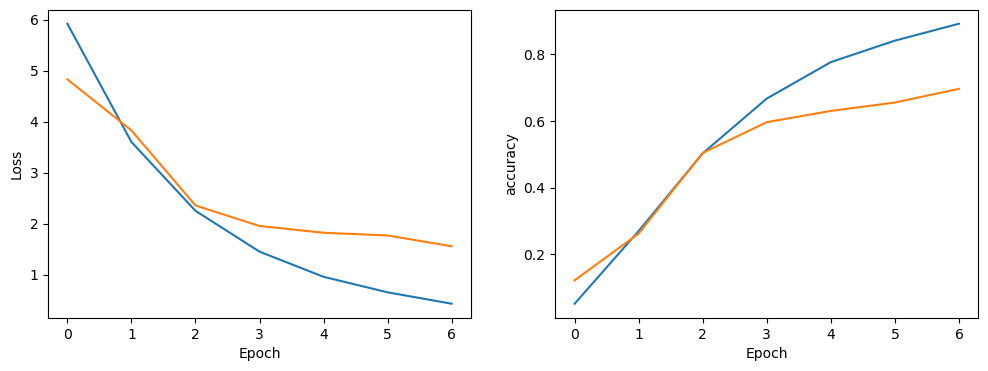

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #7
Train: loss = 0.3018437466643592, accuracy = 0.9239895303345668
Val: loss = 1.5997798835977595, accuracy = 0.7005978407861523


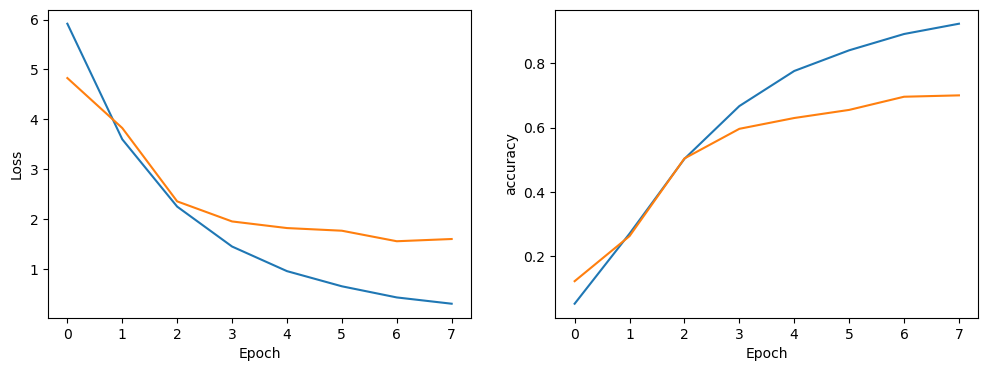

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #8
Train: loss = 0.24604317565706182, accuracy = 0.9360401248843664
Val: loss = 1.5927790263865858, accuracy = 0.7097936575910566


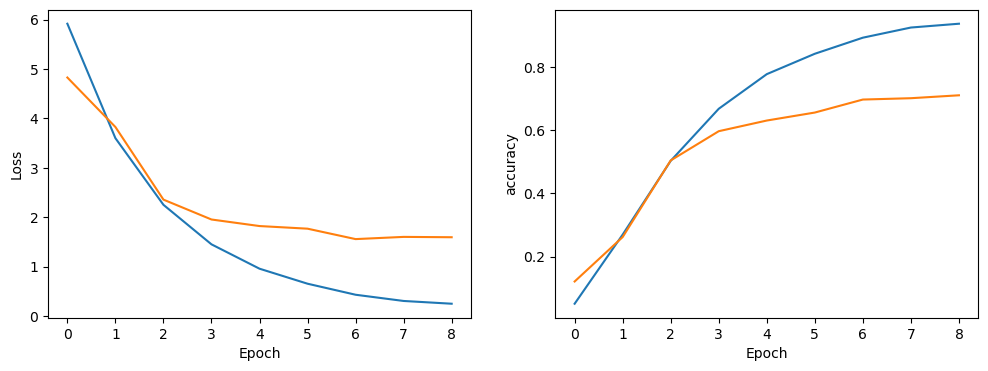

  0%|          | 0/188 [00:00<?, ?it/s]

Epoch #9
Train: loss = 0.1883172841861527, accuracy = 0.9501155132207832
Val: loss = 1.6180839842938362, accuracy = 0.7110135683375406


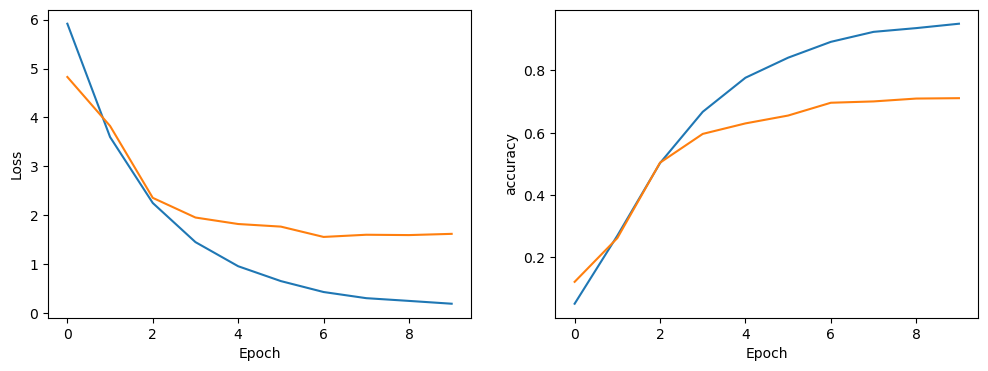

Best epoch = 9, <function accuracy at 0x000002065344B6A0> = 0.7110135683375406


In [58]:
resnet_50, resnet50_stats = train(resnet_50, 10, train_loader, val_loader, optimizer, criterion, accuracy, './models/resnet50_CE', scheduler, '_atempt_2')

Разморозка ещё одного слоя улучшений не привнесла. Нас интересуют самые последние слои, потому что они извлекают высокоуровневые признаки, а начальные слои и так хорошо обучены вытаскивать низкоуровневые штуки

<h1>ArcFace loss</h1>